<a href="https://colab.research.google.com/github/mskingk/mura-shortcut-learning/blob/main/Copy_of_mura_shortcut_learningFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!umount /content/drive

umount: /content/drive: no mount point specified.


In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install timm grad-cam -q

import torch
print(torch.cuda.get_device_name(0))

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 104.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
NVIDIA A100-SXM4-80GB


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Ml_Project class"))

['ML_project.gdoc', 'MURA_FOR_OUR_PROJ', 'mura_checkpoints', 'gradcam', 'mura_results.csv', 'combined_dataset']


In [ ]:
"""
MURA Shortcut Learning Project
Full pipeline: dataloader → train → evaluate (clean + masked) → GradCAM
"""

import os, glob, numpy as np, pandas as pd
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

# Config
DATA_ROOT  = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
BODY_PARTS = ["XR_WRIST", "XR_ELBOW", "XR_SHOULDER"]
BATCH_SIZE = 32
EPOCHS     = 20
SEEDS      = [42, 0, 1, 7, 21]
LR         = 1e-4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR   = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Using device: {DEVICE}")


# DATASET
class MURADataset(Dataset):
    def __init__(self, root, split, body_parts, transform=None, mask_artifacts=False):
        self.transform = transform
        self.mask_artifacts = mask_artifacts
        self.samples = []
        for bp in body_parts:
            bp_path = os.path.join(root, split, bp)
            if not os.path.exists(bp_path):
                print(f"Warning: {bp_path} not found, skipping.")
                continue
            for study_dir in glob.glob(os.path.join(bp_path, "*", "*")):
                label = 1 if "positive" in study_dir.lower() else 0
                for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                    self.samples.append((img_path, label))
        print(f"[{split}] Loaded {len(self.samples)} images across {body_parts}")

    def __len__(self):
        return len(self.samples)

    def _apply_mask(self, img_tensor):
        _, H, W = img_tensor.shape
        corner = int(0.15 * min(H, W))
        border = 10
        masked = img_tensor.clone()
        masked[:, :corner, :corner] = 0
        masked[:, :corner, -corner:] = 0
        masked[:, -corner:, :corner] = 0
        masked[:, -corner:, -corner:] = 0
        masked[:, :border, :] = 0
        masked[:, -border:, :] = 0
        masked[:, :, :border] = 0
        masked[:, :, -border:] = 0
        return masked

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.mask_artifacts:
            img = self._apply_mask(img)
        return img, label, img_path


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# MODELS
def get_model(name):
    if name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights="IMAGENET1K_V1")
        m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=1)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m.to(DEVICE)


# TRAINING
def train_model(model, train_loader, val_loader, model_name, body_part, seed):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.BCEWithLogitsLoss()
    best_auc = 0
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        auc = evaluate(model, val_loader)
        print(f"[{model_name} | {body_part} | seed={seed}] Epoch {epoch+1}/{EPOCHS} "
              f"Loss: {running_loss/len(train_loader):.4f}  Val AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            ckpt_path = os.path.join(SAVE_DIR, f"{model_name}_{body_part}_seed{seed}_best.pt")
            torch.save(model.state_dict(), ckpt_path)
    print(f"Best AUC for {model_name} on {body_part} seed={seed}: {best_auc:.4f}")
    return best_auc


# EVALUATION
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs).squeeze(1).cpu()
            preds = torch.sigmoid(logits).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    if len(set(all_labels)) < 2:
        return 0.5
    return roc_auc_score(all_labels, all_preds)


# ENSEMBLE EVALUATION
def evaluate_ensemble(models_dict, loader, weights):
    for m in models_dict.values():
        m.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(DEVICE)
            weighted_sum = torch.zeros(imgs.size(0))
            total_weight = sum(weights.values())
            for name, model in models_dict.items():
                logits = model(imgs).squeeze(1).cpu()
                probs = torch.sigmoid(logits)
                weighted_sum += (weights[name] / total_weight) * probs
            all_preds.extend(weighted_sum.numpy())
            all_labels.extend(labels.numpy())
    return roc_auc_score(all_labels, all_preds)


# GRADCAM
def generate_gradcam(model, model_name, loader, save_dir, n_images=5):
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    import cv2
    os.makedirs(save_dir, exist_ok=True)
    if model_name == "resnet50":
        target_layers = [model.layer4[-1]]
    elif model_name == "efficientnet_b0":
        target_layers = [model.features[-1]]
    elif model_name == "densenet169":
        target_layers = [model.features.denseblock4]
    elif model_name == "vit":
        target_layers = [model.blocks[-1].norm1]
    else:
        return
    def reshape_transform(tensor, height=14, width=14):
        result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
        return result.transpose(2, 3).transpose(1, 2)
    if model_name == "vit":
        cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
    else:
        cam = GradCAM(model=model, target_layers=target_layers)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    count = 0
    for imgs, labels, paths in loader:
        for i in range(imgs.size(0)):
            if count >= n_images:
                break
            img_tensor = imgs[i].unsqueeze(0).to(DEVICE)
            grayscale_cam = cam(input_tensor=img_tensor)[0]
            img_np = imgs[i].permute(1,2,0).numpy()
            img_np = (img_np * std + mean).clip(0, 1).astype(np.float32)
            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
            label_str = "abnormal" if labels[i].item() == 1 else "normal"
            out_path = os.path.join(save_dir, f"{model_name}_{label_str}_{count}.png")
            cv2.imwrite(out_path, cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
            count += 1
        if count >= n_images:
            break
    print(f"Saved {count} GradCAM images to {save_dir}")


# MAIN
results = {}

ensemble_configs = {
    "resnet50+efficientnet_b0":              ["resnet50", "efficientnet_b0"],
    "resnet50+densenet169":                  ["resnet50", "densenet169"],
    "efficientnet_b0+densenet169":           ["efficientnet_b0", "densenet169"],
    "resnet50+efficientnet_b0+densenet169":  ["resnet50", "efficientnet_b0", "densenet169"],
    "resnet50+vit":                          ["resnet50", "vit"],
    "efficientnet_b0+vit":                   ["efficientnet_b0", "vit"],
    "resnet50+efficientnet_b0+vit":          ["resnet50", "efficientnet_b0", "vit"],
}

for bp in BODY_PARTS:
    print(f"\n{'='*60}\nBody part: {bp}\n{'='*60}")
    results[bp] = {}

    train_ds      = MURADataset(DATA_ROOT, "train", [bp], transform=train_transform)
    val_ds        = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform)
    val_masked_ds = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform, mask_artifacts=True)

    train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    val_masked_loader = DataLoader(val_masked_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    val_aucs       = {}
    trained_models = {}

    for model_name in ["resnet50", "efficientnet_b0", "densenet169", "vit"]:
        seed_clean_aucs  = []
        seed_masked_aucs = []

        for seed in SEEDS:
            torch.manual_seed(seed)
            np.random.seed(seed)

            print(f"\n--- Training {model_name} | seed={seed} ---")
            model = get_model(model_name)
            train_model(model, train_loader, val_loader, model_name, bp, seed)

            ckpt = os.path.join(SAVE_DIR, f"{model_name}_{bp}_seed{seed}_best.pt")
            model.load_state_dict(torch.load(ckpt))

            clean_auc  = evaluate(model, val_loader)
            masked_auc = evaluate(model, val_masked_loader)
            seed_clean_aucs.append(clean_auc)
            seed_masked_aucs.append(masked_auc)

        mean_clean  = round(float(np.mean(seed_clean_aucs)),  4)
        std_clean   = round(float(np.std(seed_clean_aucs)),   4)
        mean_masked = round(float(np.mean(seed_masked_aucs)), 4)
        std_masked  = round(float(np.std(seed_masked_aucs)),  4)
        delta       = round(mean_clean - mean_masked, 4)

        results[bp][model_name] = {
            "clean_auc":  mean_clean,
            "clean_std":  std_clean,
            "masked_auc": mean_masked,
            "masked_std": std_masked,
            "delta_auc":  delta,
        }
        val_aucs[model_name]       = mean_clean
        trained_models[model_name] = model  # last seed's model for GradCAM

        print(f"{model_name} | Clean: {mean_clean:.4f}±{std_clean:.4f} | "
              f"Masked: {mean_masked:.4f}±{std_masked:.4f} | ΔAUC: {delta:.4f}")

        gradcam_dir = f"/content/drive/MyDrive/Ml_Project class/gradcam/{bp}/{model_name}"
        generate_gradcam(model, model_name, val_loader, gradcam_dir, n_images=5)

    for ens_name, members in ensemble_configs.items():
        ens_models  = {m: trained_models[m] for m in members}
        ens_weights = {m: val_aucs[m] for m in members}
        clean_auc  = evaluate_ensemble(ens_models, val_loader,        ens_weights)
        masked_auc = evaluate_ensemble(ens_models, val_masked_loader, ens_weights)
        delta_auc  = round(clean_auc - masked_auc, 4)
        results[bp][ens_name] = {
            "clean_auc":  round(clean_auc,  4),
            "clean_std":  None,
            "masked_auc": round(masked_auc, 4),
            "masked_std": None,
            "delta_auc":  delta_auc,
        }
        print(f"{ens_name} | Clean: {clean_auc:.4f} | Masked: {masked_auc:.4f} | ΔAUC: {delta_auc:.4f}")

# SAVE RESULTS
print("\n\n===== FINAL RESULTS =====")
print(f"{'Model':<40} {'Part':<12} {'Clean AUC':>10} {'±':>4} {'Masked AUC':>11} {'±':>4} {'ΔAUC':>7}")
print("-" * 92)
for bp, models_res in results.items():
    for model_name, metrics in models_res.items():
        std_c = f"{metrics['clean_std']:.4f}" if metrics['clean_std'] is not None else "  -  "
        std_m = f"{metrics['masked_std']:.4f}" if metrics['masked_std'] is not None else "  -  "
        print(f"{model_name:<40} {bp:<12} {metrics['clean_auc']:>10.4f} {std_c:>6} "
              f"{metrics['masked_auc']:>11.4f} {std_m:>6} {metrics['delta_auc']:>7.4f}")

rows = []
for bp, models_res in results.items():
    for model_name, metrics in models_res.items():
        rows.append({"body_part": bp, "model": model_name, **metrics})
df = pd.DataFrame(rows)
csv_path = "/content/drive/MyDrive/Ml_Project class/mura_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")

Using device: cuda

Body part: XR_WRIST
[train] Loaded 9752 images across ['XR_WRIST']
[valid] Loaded 659 images across ['XR_WRIST']
[valid] Loaded 659 images across ['XR_WRIST']

--- Training resnet50 | seed=42 ---
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


[resnet50 | XR_WRIST | seed=42] Epoch 1/20 Loss: 0.4497  Val AUC: 0.8803
[resnet50 | XR_WRIST | seed=42] Epoch 2/20 Loss: 0.3793  Val AUC: 0.8929
[resnet50 | XR_WRIST | seed=42] Epoch 3/20 Loss: 0.3576  Val AUC: 0.9025
[resnet50 | XR_WRIST | seed=42] Epoch 4/20 Loss: 0.3286  Val AUC: 0.8843
[resnet50 | XR_WRIST | seed=42] Epoch 5/20 Loss: 0.3124  Val AUC: 0.8858
[resnet50 | XR_WRIST | seed=42] Epoch 6/20 Loss: 0.2837  Val AUC: 0.8881
[resnet50 | XR_WRIST | seed=42] Epoch 7/20 Loss: 0.2609  Val AUC: 0.8649
[resnet50 | XR_WRIST | seed=42] Epoch 8/20 Loss: 0.2360  Val AUC: 0.8769
[resnet50 | XR_WRIST | seed=42] Epoch 9/20 Loss: 0.2083  Val AUC: 0.8830
[resnet50 | XR_WRIST | seed=42] Epoch 10/20 Loss: 0.1848  Val AUC: 0.8865
[resnet50 | XR_WRIST | seed=42] Epoch 11/20 Loss: 0.1483  Val AUC: 0.8751
[resnet50 | XR_WRIST | seed=42] Epoch 12/20 Loss: 0.1152  Val AUC: 0.8766
[resnet50 | XR_WRIST | seed=42] Epoch 13/20 Loss: 0.1015  Val AUC: 0.8900
[resnet50 | XR_WRIST | seed=42] Epoch 14/20 Los

100%|██████████| 20.5M/20.5M [00:00<00:00, 178MB/s]


[efficientnet_b0 | XR_WRIST | seed=42] Epoch 1/20 Loss: 0.4762  Val AUC: 0.8736
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 2/20 Loss: 0.3776  Val AUC: 0.8922
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 3/20 Loss: 0.3482  Val AUC: 0.9188
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 4/20 Loss: 0.3178  Val AUC: 0.9037
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 5/20 Loss: 0.2985  Val AUC: 0.8943
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 6/20 Loss: 0.2736  Val AUC: 0.8987
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 7/20 Loss: 0.2469  Val AUC: 0.8986
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 8/20 Loss: 0.2282  Val AUC: 0.9044
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 9/20 Loss: 0.2050  Val AUC: 0.8937
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 10/20 Loss: 0.1877  Val AUC: 0.9031
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 11/20 Loss: 0.1623  Val AUC: 0.8997
[efficientnet_b0 | XR_WRIST | seed=42] Epoch 12/20 Loss: 0.1507  Val AUC: 0.8924
[efficientnet_b0 | XR_WRIST | seed=42

100%|██████████| 54.7M/54.7M [00:00<00:00, 234MB/s]


[densenet169 | XR_WRIST | seed=42] Epoch 1/20 Loss: 0.4419  Val AUC: 0.8882
[densenet169 | XR_WRIST | seed=42] Epoch 2/20 Loss: 0.3672  Val AUC: 0.9064
[densenet169 | XR_WRIST | seed=42] Epoch 3/20 Loss: 0.3420  Val AUC: 0.8920
[densenet169 | XR_WRIST | seed=42] Epoch 4/20 Loss: 0.3096  Val AUC: 0.8983
[densenet169 | XR_WRIST | seed=42] Epoch 5/20 Loss: 0.2812  Val AUC: 0.8896
[densenet169 | XR_WRIST | seed=42] Epoch 6/20 Loss: 0.2558  Val AUC: 0.9058
[densenet169 | XR_WRIST | seed=42] Epoch 7/20 Loss: 0.2302  Val AUC: 0.9072
[densenet169 | XR_WRIST | seed=42] Epoch 8/20 Loss: 0.1995  Val AUC: 0.8932
[densenet169 | XR_WRIST | seed=42] Epoch 9/20 Loss: 0.1759  Val AUC: 0.8927
[densenet169 | XR_WRIST | seed=42] Epoch 10/20 Loss: 0.1368  Val AUC: 0.8978
[densenet169 | XR_WRIST | seed=42] Epoch 11/20 Loss: 0.1141  Val AUC: 0.8875
[densenet169 | XR_WRIST | seed=42] Epoch 12/20 Loss: 0.0867  Val AUC: 0.8930
[densenet169 | XR_WRIST | seed=42] Epoch 13/20 Loss: 0.0695  Val AUC: 0.8999
[densene

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[vit | XR_WRIST | seed=42] Epoch 1/20 Loss: 0.6451  Val AUC: 0.7584
[vit | XR_WRIST | seed=42] Epoch 2/20 Loss: 0.5251  Val AUC: 0.8070
[vit | XR_WRIST | seed=42] Epoch 3/20 Loss: 0.4699  Val AUC: 0.8408
[vit | XR_WRIST | seed=42] Epoch 4/20 Loss: 0.4440  Val AUC: 0.8350
[vit | XR_WRIST | seed=42] Epoch 5/20 Loss: 0.4241  Val AUC: 0.8526
[vit | XR_WRIST | seed=42] Epoch 6/20 Loss: 0.4173  Val AUC: 0.8707
[vit | XR_WRIST | seed=42] Epoch 7/20 Loss: 0.3949  Val AUC: 0.8829
[vit | XR_WRIST | seed=42] Epoch 8/20 Loss: 0.3869  Val AUC: 0.8706
[vit | XR_WRIST | seed=42] Epoch 9/20 Loss: 0.3623  Val AUC: 0.8726
[vit | XR_WRIST | seed=42] Epoch 10/20 Loss: 0.3442  Val AUC: 0.8903
[vit | XR_WRIST | seed=42] Epoch 11/20 Loss: 0.3250  Val AUC: 0.8855
[vit | XR_WRIST | seed=42] Epoch 12/20 Loss: 0.3045  Val AUC: 0.8669
[vit | XR_WRIST | seed=42] Epoch 13/20 Loss: 0.2800  Val AUC: 0.8754
[vit | XR_WRIST | seed=42] Epoch 14/20 Loss: 0.2512  Val AUC: 0.8764
[vit | XR_WRIST | seed=42] Epoch 15/20 Loss

All body part trained with diffrent model

In [ ]:
"""
MURA Shortcut Learning Project
Full pipeline: dataloader → train → evaluate (clean + masked) → GradCAM
"""

import os, glob, numpy as np, pandas as pd
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

# Config
DATA_ROOT  = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
BODY_PARTS = ["XR_HAND", "XR_HUMERUS"]
BATCH_SIZE = 32
EPOCHS     = 20
SEEDS      = [42, 0, 1, 7, 21]
LR         = 1e-4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR   = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Using device: {DEVICE}")


# DATASET
class MURADataset(Dataset):
    def __init__(self, root, split, body_parts, transform=None, mask_artifacts=False):
        self.transform = transform
        self.mask_artifacts = mask_artifacts
        self.samples = []
        for bp in body_parts:
            bp_path = os.path.join(root, split, bp)
            if not os.path.exists(bp_path):
                print(f"Warning: {bp_path} not found, skipping.")
                continue
            for study_dir in glob.glob(os.path.join(bp_path, "*", "*")):
                label = 1 if "positive" in study_dir.lower() else 0
                for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                    self.samples.append((img_path, label))
        print(f"[{split}] Loaded {len(self.samples)} images across {body_parts}")

    def __len__(self):
        return len(self.samples)

    def _apply_mask(self, img_tensor):
        _, H, W = img_tensor.shape
        corner = int(0.15 * min(H, W))
        border = 10
        masked = img_tensor.clone()
        masked[:, :corner, :corner] = 0
        masked[:, :corner, -corner:] = 0
        masked[:, -corner:, :corner] = 0
        masked[:, -corner:, -corner:] = 0
        masked[:, :border, :] = 0
        masked[:, -border:, :] = 0
        masked[:, :, :border] = 0
        masked[:, :, -border:] = 0
        return masked

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.mask_artifacts:
            img = self._apply_mask(img)
        return img, label, img_path


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# MODELS
def get_model(name):
    if name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights="IMAGENET1K_V1")
        m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=1)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m.to(DEVICE)


# TRAINING
def train_model(model, train_loader, val_loader, model_name, body_part, seed):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.BCEWithLogitsLoss()
    best_auc = 0
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        auc = evaluate(model, val_loader)
        print(f"[{model_name} | {body_part} | seed={seed}] Epoch {epoch+1}/{EPOCHS} "
              f"Loss: {running_loss/len(train_loader):.4f}  Val AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            ckpt_path = os.path.join(SAVE_DIR, f"{model_name}_{body_part}_seed{seed}_best.pt")
            torch.save(model.state_dict(), ckpt_path)
    print(f"Best AUC for {model_name} on {body_part} seed={seed}: {best_auc:.4f}")
    return best_auc


# EVALUATION
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs).squeeze(1).cpu()
            preds = torch.sigmoid(logits).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    if len(set(all_labels)) < 2:
        return 0.5
    return roc_auc_score(all_labels, all_preds)


# ENSEMBLE EVALUATION
def evaluate_ensemble(models_dict, loader, weights):
    for m in models_dict.values():
        m.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(DEVICE)
            weighted_sum = torch.zeros(imgs.size(0))
            total_weight = sum(weights.values())
            for name, model in models_dict.items():
                logits = model(imgs).squeeze(1).cpu()
                probs = torch.sigmoid(logits)
                weighted_sum += (weights[name] / total_weight) * probs
            all_preds.extend(weighted_sum.numpy())
            all_labels.extend(labels.numpy())
    return roc_auc_score(all_labels, all_preds)


# GRADCAM
def generate_gradcam(model, model_name, loader, save_dir, n_images=5):
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    import cv2
    os.makedirs(save_dir, exist_ok=True)
    if model_name == "resnet50":
        target_layers = [model.layer4[-1]]
    elif model_name == "efficientnet_b0":
        target_layers = [model.features[-1]]
    elif model_name == "densenet169":
        target_layers = [model.features.denseblock4]
    elif model_name == "vit":
        target_layers = [model.blocks[-1].norm1]
    else:
        return
    def reshape_transform(tensor, height=14, width=14):
        result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
        return result.transpose(2, 3).transpose(1, 2)
    if model_name == "vit":
        cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
    else:
        cam = GradCAM(model=model, target_layers=target_layers)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    count = 0
    for imgs, labels, paths in loader:
        for i in range(imgs.size(0)):
            if count >= n_images:
                break
            img_tensor = imgs[i].unsqueeze(0).to(DEVICE)
            grayscale_cam = cam(input_tensor=img_tensor)[0]
            img_np = imgs[i].permute(1,2,0).numpy()
            img_np = (img_np * std + mean).clip(0, 1).astype(np.float32)
            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
            label_str = "abnormal" if labels[i].item() == 1 else "normal"
            out_path = os.path.join(save_dir, f"{model_name}_{label_str}_{count}.png")
            cv2.imwrite(out_path, cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))
            count += 1
        if count >= n_images:
            break
    print(f"Saved {count} GradCAM images to {save_dir}")


# MAIN
results = {}

ensemble_configs = {
    "resnet50+efficientnet_b0":              ["resnet50", "efficientnet_b0"],
    "resnet50+densenet169":                  ["resnet50", "densenet169"],
    "efficientnet_b0+densenet169":           ["efficientnet_b0", "densenet169"],
    "resnet50+efficientnet_b0+densenet169":  ["resnet50", "efficientnet_b0", "densenet169"],
    "resnet50+vit":                          ["resnet50", "vit"],
    "efficientnet_b0+vit":                   ["efficientnet_b0", "vit"],
    "resnet50+efficientnet_b0+vit":          ["resnet50", "efficientnet_b0", "vit"],
}

for bp in BODY_PARTS:
    print(f"\n{'='*60}\nBody part: {bp}\n{'='*60}")
    results[bp] = {}

    train_ds      = MURADataset(DATA_ROOT, "train", [bp], transform=train_transform)
    val_ds        = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform)
    val_masked_ds = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform, mask_artifacts=True)

    train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    val_masked_loader = DataLoader(val_masked_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    val_aucs       = {}
    trained_models = {}

    for model_name in ["resnet50", "efficientnet_b0", "densenet169", "vit"]:
        seed_clean_aucs  = []
        seed_masked_aucs = []

        for seed in SEEDS:
            torch.manual_seed(seed)
            np.random.seed(seed)

            ckpt = os.path.join(SAVE_DIR, f"{model_name}_{bp}_seed{seed}_best.pt")

            if os.path.exists(ckpt):
                print(f"Skipping {model_name} | {bp} | seed={seed} — checkpoint exists")
                model = get_model(model_name)
                model.load_state_dict(torch.load(ckpt))
            else:
                print(f"\n--- Training {model_name} | seed={seed} ---")
                model = get_model(model_name)
                train_model(model, train_loader, val_loader, model_name, bp, seed)
                model.load_state_dict(torch.load(ckpt))


            clean_auc  = evaluate(model, val_loader)
            masked_auc = evaluate(model, val_masked_loader)
            seed_clean_aucs.append(clean_auc)
            seed_masked_aucs.append(masked_auc)

        mean_clean  = round(float(np.mean(seed_clean_aucs)),  4)
        std_clean   = round(float(np.std(seed_clean_aucs)),   4)
        mean_masked = round(float(np.mean(seed_masked_aucs)), 4)
        std_masked  = round(float(np.std(seed_masked_aucs)),  4)
        delta       = round(mean_clean - mean_masked, 4)

        results[bp][model_name] = {
            "clean_auc":  mean_clean,
            "clean_std":  std_clean,
            "masked_auc": mean_masked,
            "masked_std": std_masked,
            "delta_auc":  delta,
        }
        val_aucs[model_name]       = mean_clean
        trained_models[model_name] = model  # last seed's model for GradCAM

        print(f"{model_name} | Clean: {mean_clean:.4f}±{std_clean:.4f} | "
              f"Masked: {mean_masked:.4f}±{std_masked:.4f} | ΔAUC: {delta:.4f}")

        gradcam_dir = f"/content/drive/MyDrive/Ml_Project class/gradcam/{bp}/{model_name}"
        generate_gradcam(model, model_name, val_loader, gradcam_dir, n_images=5)

    for ens_name, members in ensemble_configs.items():
        ens_models  = {m: trained_models[m] for m in members}
        ens_weights = {m: val_aucs[m] for m in members}
        clean_auc  = evaluate_ensemble(ens_models, val_loader,        ens_weights)
        masked_auc = evaluate_ensemble(ens_models, val_masked_loader, ens_weights)
        delta_auc  = round(clean_auc - masked_auc, 4)
        results[bp][ens_name] = {
            "clean_auc":  round(clean_auc,  4),
            "clean_std":  None,
            "masked_auc": round(masked_auc, 4),
            "masked_std": None,
            "delta_auc":  delta_auc,
        }
        print(f"{ens_name} | Clean: {clean_auc:.4f} | Masked: {masked_auc:.4f} | ΔAUC: {delta_auc:.4f}")

# SAVE RESULTS
print("\n\n===== FINAL RESULTS =====")
print(f"{'Model':<40} {'Part':<12} {'Clean AUC':>10} {'±':>4} {'Masked AUC':>11} {'±':>4} {'ΔAUC':>7}")
print("-" * 92)
for bp, models_res in results.items():
    for model_name, metrics in models_res.items():
        std_c = f"{metrics['clean_std']:.4f}" if metrics['clean_std'] is not None else "  -  "
        std_m = f"{metrics['masked_std']:.4f}" if metrics['masked_std'] is not None else "  -  "
        print(f"{model_name:<40} {bp:<12} {metrics['clean_auc']:>10.4f} {std_c:>6} "
              f"{metrics['masked_auc']:>11.4f} {std_m:>6} {metrics['delta_auc']:>7.4f}")

rows = []
for bp, models_res in results.items():
    for model_name, metrics in models_res.items():
        rows.append({"body_part": bp, "model": model_name, **metrics})
df = pd.DataFrame(rows)
csv_path = "/content/drive/MyDrive/Ml_Project class/mura_results.csv"
if os.path.exists(csv_path):
    old_df = pd.read_csv(csv_path)
    df = pd.concat([old_df, df], ignore_index=True)

df.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")

Using device: cuda

Body part: XR_HAND
[train] Loaded 5543 images across ['XR_HAND']
[valid] Loaded 460 images across ['XR_HAND']
[valid] Loaded 460 images across ['XR_HAND']
Skipping resnet50 | XR_HAND | seed=42 — checkpoint exists
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 240MB/s]


Skipping resnet50 | XR_HAND | seed=0 — checkpoint exists
Skipping resnet50 | XR_HAND | seed=1 — checkpoint exists
Skipping resnet50 | XR_HAND | seed=7 — checkpoint exists
Skipping resnet50 | XR_HAND | seed=21 — checkpoint exists
resnet50 | Clean: 0.8412±0.0072 | Masked: 0.8118±0.0132 | ΔAUC: 0.0294
Saved 5 GradCAM images to /content/drive/MyDrive/Ml_Project class/gradcam/XR_HAND/resnet50
Skipping efficientnet_b0 | XR_HAND | seed=42 — checkpoint exists
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 236MB/s]


Skipping efficientnet_b0 | XR_HAND | seed=0 — checkpoint exists
Skipping efficientnet_b0 | XR_HAND | seed=1 — checkpoint exists
Skipping efficientnet_b0 | XR_HAND | seed=7 — checkpoint exists
Skipping efficientnet_b0 | XR_HAND | seed=21 — checkpoint exists
efficientnet_b0 | Clean: 0.8349±0.0084 | Masked: 0.7916±0.0055 | ΔAUC: 0.0433
Saved 5 GradCAM images to /content/drive/MyDrive/Ml_Project class/gradcam/XR_HAND/efficientnet_b0
Skipping densenet169 | XR_HAND | seed=42 — checkpoint exists
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


...

Skipping densenet169 | XR_HAND | seed=0 — checkpoint exists
Skipping densenet169 | XR_HAND | seed=1 — checkpoint exists
Skipping densenet169 | XR_HAND | seed=7 — checkpoint exists
Skipping densenet169 | XR_HAND | seed=21 — checkpoint exists
densenet169 | Clean: 0.8463±0.0097 | Masked: 0.8231±0.0182 | ΔAUC: 0.0232
Saved 5 GradCAM images to /content/drive/MyDrive/Ml_Project class/gradcam/XR_HAND/densenet169
Skipping vit | XR_HAND | seed=42 — checkpoint exists


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


--- Training vit | seed=0 ---
[vit | XR_HAND | seed=0] Epoch 1/20 Loss: 0.6045  Val AUC: 0.5755
[vit | XR_HAND | seed=0] Epoch 2/20 Loss: 0.5860  Val AUC: 0.5724
[vit | XR_HAND | seed=0] Epoch 3/20 Loss: 0.5807  Val AUC: 0.6018
[vit | XR_HAND | seed=0] Epoch 4/20 Loss: 0.5836  Val AUC: 0.5674
[vit | XR_HAND | seed=0] Epoch 5/20 Loss: 0.5794  Val AUC: 0.6347
[vit | XR_HAND | seed=0] Epoch 6/20 Loss: 0.5796  Val AUC: 0.5288
[vit | XR_HAND | seed=0] Epoch 7/20 Loss: 0.5753  Val AUC: 0.6411
[vit | XR_HAND | seed=0] Epoch 8/20 Loss: 0.5814  Val AUC: 0.5366
[vit | XR_HAND | seed=0] Epoch 9/20 Loss: 0.5737  Val AUC: 0.6075
[vit | XR_HAND | seed=0] Epoch 10/20 Loss: 0.5673  Val AUC: 0.5711
[vit | XR_HAND | seed=0] Epoch 11/20 Loss: 0.5638  Val AUC: 0.5865
[vit | XR_HAND | seed=0] Epoch 12/20 Loss: 0.5506  Val AUC: 0.6598
[vit | XR_HAND | seed=0] Epoch 13/20 Loss: 0.5475  Val AUC: 0.6291
[vit | XR_HAND | seed=0] Epoch 14/20 Loss: 0.5276  Val AUC: 0.6769
[vit | XR_HAND | seed=0] Epoch 15/20 Los

[vit | XR_HAND | seed=1] Epoch 1/20 Loss: 0.6079  Val AUC: 0.5786
[vit | XR_HAND | seed=1] Epoch 2/20 Loss: 0.5929  Val AUC: 0.5807
[vit | XR_HAND | seed=1] Epoch 3/20 Loss: 0.5867  Val AUC: 0.5720
[vit | XR_HAND | seed=1] Epoch 4/20 Loss: 0.5791  Val AUC: 0.5755
[vit | XR_HAND | seed=1] Epoch 5/20 Loss: 0.5846  Val AUC: 0.5759
[vit | XR_HAND | seed=1] Epoch 6/20 Loss: 0.5796  Val AUC: 0.6287
[vit | XR_HAND | seed=1] Epoch 7/20 Loss: 0.5752  Val AUC: 0.5636
[vit | XR_HAND | seed=1] Epoch 8/20 Loss: 0.5757  Val AUC: 0.6094
[vit | XR_HAND | seed=1] Epoch 9/20 Loss: 0.5691  Val AUC: 0.6191
[vit | XR_HAND | seed=1] Epoch 10/20 Loss: 0.5626  Val AUC: 0.6587
[vit | XR_HAND | seed=1] Epoch 11/20 Loss: 0.5501  Val AUC: 0.7233
[vit | XR_HAND | seed=1] Epoch 12/20 Loss: 0.5305  Val AUC: 0.6968
[vit | XR_HAND | seed=1] Epoch 13/20 Loss: 0.5143  Val AUC: 0.7486
[vit | XR_HAND | seed=1] Epoch 14/20 Loss: 0.4938  Val AUC: 0.7511
[vit | XR_HAND | seed=1] Epoch 15/20 Loss: 0.4795  Val AUC: 0.7352
[vit

In [ ]:
# combine_mura.py
# Run once — copies all images into a single flat dataset structure
# Output: combined_dataset/train/positive/ and combined_dataset/train/negative/

import os
import shutil
import glob
from tqdm import tqdm

DATA_ROOT = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
OUT_DIR   = "/content/drive/MyDrive/Ml_Project class/combined_dataset"

BODY_PARTS = [
    "XR_WRIST", "XR_ELBOW", "XR_SHOULDER",
    "XR_HUMERUS", "XR_FOREARM", "XR_FINGER", "XR_HAND"
]

# Create output folders
for split in ["train", "valid"]:
    for label in ["positive", "negative"]:
        os.makedirs(os.path.join(OUT_DIR, split, label), exist_ok=True)

# Copy all images
for split in ["train", "valid"]:
    counts = {"positive": 0, "negative": 0}

    for bp in BODY_PARTS:
        bp_dir = os.path.join(DATA_ROOT, split, bp)
        if not os.path.exists(bp_dir):
            print(f"[WARN] Missing: {bp_dir}")
            continue

        for study_dir in glob.glob(os.path.join(bp_dir, "patient*", "study*")):
            folder = os.path.basename(study_dir).lower()
            label  = "positive" if "positive" in folder else "negative"
            dst_dir = os.path.join(OUT_DIR, split, label)

            for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                # Unique filename: bodypart_patientXXX_studyY_imageZ.png
                parts   = img_path.replace(DATA_ROOT, "").strip("/").split("/")
                new_name = f"{bp}_{parts[-3]}_{parts[-2]}_{os.path.basename(img_path)}"
                shutil.copy2(img_path, os.path.join(dst_dir, new_name))
                counts[label] += 1

    print(f"[{split.upper()}] positive={counts['positive']} negative={counts['negative']}")

print(f"\nDone. Combined dataset saved to: {OUT_DIR}")

[TRAIN] positive=14873 negative=21935
[VALID] positive=1530 negative=1667

Done. Combined dataset saved to: /content/drive/MyDrive/Ml_Project class/combined_dataset


In [ ]:
"""
Bootstrap CIs + GradCAM overlap — matches training code exactly. No retraining.
"""
import os, glob, json
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score
from PIL import Image
import timm, cv2

DATA_ROOT   = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
SAVE_DIR    = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
OUTPUT_JSON = "/content/drive/MyDrive/Ml_Project class/bootstrap_results.json"
BODY_PARTS  = ["XR_WRIST", "XR_ELBOW", "XR_SHOULDER", "XR_HUMERUS", "XR_FOREARM", "XR_FINGER", "XR_HAND"]
MODEL_NAMES = ["resnet50", "efficientnet_b0", "densenet169", "vit"]
SEEDS       = [42, 0, 1, 7, 21]
N_BOOTSTRAP = 1000
BATCH_SIZE  = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENSEMBLE_CONFIGS = {
    "resnet50+efficientnet_b0":             ["resnet50", "efficientnet_b0"],
    "resnet50+densenet169":                 ["resnet50", "densenet169"],
    "efficientnet_b0+densenet169":          ["efficientnet_b0", "densenet169"],
    "resnet50+efficientnet_b0+densenet169": ["resnet50", "efficientnet_b0", "densenet169"],
    "resnet50+vit":                         ["resnet50", "vit"],
    "efficientnet_b0+vit":                  ["efficientnet_b0", "vit"],
    "resnet50+efficientnet_b0+vit":         ["resnet50", "efficientnet_b0", "vit"],
}

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class MURADataset(Dataset):
    def __init__(self, root, split, body_parts, transform=None, mask_artifacts=False):
        self.transform = transform
        self.mask_artifacts = mask_artifacts
        self.samples = []
        for bp in body_parts:
            bp_path = os.path.join(root, split, bp)
            if not os.path.exists(bp_path):
                continue
            for study_dir in glob.glob(os.path.join(bp_path, "*", "*")):
                label = 1 if "positive" in study_dir.lower() else 0
                for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                    self.samples.append((img_path, label))

    def __len__(self): return len(self.samples)

    def _apply_mask(self, t):
        _, H, W = t.shape
        c, b = int(0.15 * min(H, W)), 10
        m = t.clone()
        m[:, :c, :c] = m[:, :c, -c:] = m[:, -c:, :c] = m[:, -c:, -c:] = 0
        m[:, :b, :] = m[:, -b:, :] = m[:, :, :b] = m[:, :, -b:] = 0
        return m

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        if self.mask_artifacts: img = self._apply_mask(img)
        return img, label, path

def get_model(name):
    if name == "resnet50":
        m = models.resnet50(weights=None); m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights=None)
        m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=1)
    return m.to(DEVICE)

def load_model(name, bp, seed):
    ckpt = os.path.join(SAVE_DIR, f"{name}_{bp}_seed{seed}_best.pt")
    if not os.path.exists(ckpt): print(f"  Missing: {ckpt}"); return None
    m = get_model(name)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return m.eval()

@torch.no_grad()
def get_probs(model, loader):
    probs, labels = [], []
    for imgs, lbls, _ in loader:
        out = model(imgs.to(DEVICE)).squeeze(1)
        probs.extend(torch.sigmoid(out).cpu().numpy())
        labels.extend(lbls.numpy())
    return np.array(probs), np.array(labels)

def bootstrap_auc(probs, labels, n=N_BOOTSTRAP):
    rng = np.random.default_rng(42)
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(labels), len(labels))
        s = labels[idx].sum()
        if s == 0 or s == len(idx): continue
        aucs.append(roc_auc_score(labels[idx], probs[idx]))
    return float(np.mean(aucs)), float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

class GradCAMSimple:
    def __init__(self, model, layer):
        self.grads = self.acts = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        layer.register_backward_hook(lambda m,i,o: setattr(self,'grads',o[0].detach()))

    def get_cam(self, model, x):
        x = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
        model(x).sum().backward()
        model.zero_grad()
        w = self.grads.mean(dim=[2,3], keepdim=True)
        cam = torch.relu((w * self.acts).sum(1).squeeze())
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        return cam.cpu().numpy()

def get_target_layer(model, name):
    if name == "resnet50":       return model.layer4[-1]
    if name == "efficientnet_b0": return model.features[-1]
    if name == "densenet169":    return model.features.denseblock4
    return None

def compute_overlap(cam, sz=224, cf=0.15, b=10):
    r = cv2.resize(cam, (sz, sz)); total = r.sum()
    if total == 0: return 0.0
    c = int(cf * sz)
    mask = np.zeros((sz, sz), dtype=bool)
    mask[:c,:c] = mask[:c,-c:] = mask[-c:,:c] = mask[-c:,-c:] = True
    mask[:b,:] = mask[-b:,:] = mask[:,:b] = mask[:,-b:] = True
    return float(r[mask].sum() / total)

def gradcam_overlap(model, name, dataset, n=200):
    layer = get_target_layer(model, name)
    if layer is None: return None, None
    gc = GradCAMSimple(model, layer)
    overlaps = []
    for i in np.random.choice(len(dataset), min(n, len(dataset)), replace=False):
        x, _, _ = dataset[i]
        try: overlaps.append(compute_overlap(gc.get_cam(model, x)))
        except: continue
    return (float(np.mean(overlaps)), float(np.std(overlaps))) if overlaps else (None, None)

def main():
    results = {}
    for bp in BODY_PARTS:
        print(f"\n{'='*60}\n{bp}\n{'='*60}")
        results[bp] = {}
        val_ds   = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform)
        val_mds  = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform, mask_artifacts=True)
        vl  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        vml = DataLoader(val_mds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        loaded, sprobs = {}, {}
        for mn in MODEL_NAMES:
            cl, ml, lref = [], [], None
            for seed in SEEDS:
                m = load_model(mn, bp, seed)
                if m is None: continue
                cp, lbs = get_probs(m, vl); mp, _ = get_probs(m, vml)
                cl.append(cp); ml.append(mp)
                if lref is None: lref = lbs
                if seed == 42: loaded[mn] = m
            if not cl: continue
            sprobs[mn] = {"clean": cl, "masked": ml, "labels": lref}
            ac = np.mean(cl, 0); am = np.mean(ml, 0)
            cm, clo, chi = bootstrap_auc(ac, lref)
            mm, mlo, mhi = bootstrap_auc(am, lref)
            d, dlo, dhi = cm-mm, clo-mhi, chi-mlo
            ov, os_ = gradcam_overlap(loaded.get(mn), mn, val_ds)
            print(f"\n{mn}:")
            print(f"  Clean  AUC : {cm:.4f} [{clo:.4f}, {chi:.4f}]")
            print(f"  Masked AUC : {mm:.4f} [{mlo:.4f}, {mhi:.4f}]")
            print(f"  ΔAUC       : {d:.4f} [{dlo:.4f}, {dhi:.4f}]")
            if ov: print(f"  GradCAM overlap: {ov:.4f} ± {os_:.4f}")
            results[bp][mn] = dict(clean_auc=cm,clean_lo=clo,clean_hi=chi,
                masked_auc=mm,masked_lo=mlo,masked_hi=mhi,
                delta_auc=d,delta_lo=dlo,delta_hi=dhi,
                gradcam_overlap_mean=ov,gradcam_overlap_std=os_)

        for en, members in ENSEMBLE_CONFIGS.items():
            if not all(m in sprobs for m in members): continue
            ac = np.mean([np.mean(sprobs[m]["clean"],  0) for m in members], 0)
            am = np.mean([np.mean(sprobs[m]["masked"], 0) for m in members], 0)
            lr = sprobs[members[0]]["labels"]
            cm,clo,chi = bootstrap_auc(ac,lr); mm,mlo,mhi = bootstrap_auc(am,lr)
            d,dlo,dhi = cm-mm,clo-mhi,chi-mlo
            print(f"\n{en}:")
            print(f"  Clean  AUC : {cm:.4f} [{clo:.4f}, {chi:.4f}]")
            print(f"  Masked AUC : {mm:.4f} [{mlo:.4f}, {mhi:.4f}]")
            print(f"  ΔAUC       : {d:.4f} [{dlo:.4f}, {dhi:.4f}]")
            results[bp][en] = dict(clean_auc=cm,clean_lo=clo,clean_hi=chi,
                masked_auc=mm,masked_lo=mlo,masked_hi=mhi,
                delta_auc=d,delta_lo=dlo,delta_hi=dhi,
                gradcam_overlap_mean=None,gradcam_overlap_std=None)

    with open(OUTPUT_JSON, "w") as f: json.dump(results, f, indent=2)
    print(f"\nSaved to {OUTPUT_JSON}")

if __name__ == "__main__":
    main()


XR_WRIST


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)



resnet50:
  Clean  AUC : 0.9126 [0.8884, 0.9350]
  Masked AUC : 0.9036 [0.8779, 0.9280]
  ΔAUC       : 0.0090 [-0.0396, 0.0571]
  GradCAM overlap: 0.1423 ± 0.1711


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)



efficientnet_b0:
  Clean  AUC : 0.9172 [0.8942, 0.9385]
  Masked AUC : 0.9059 [0.8814, 0.9288]
  ΔAUC       : 0.0114 [-0.0346, 0.0572]
  GradCAM overlap: 0.1807 ± 0.1689


...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)



efficientnet_b0:
  Clean  AUC : 0.9234 [0.8919, 0.9511]
  Masked AUC : 0.9142 [0.8783, 0.9458]
  ΔAUC       : 0.0091 [-0.0539, 0.0728]
  GradCAM overlap: 0.1567 ± 0.1422


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)



densenet169:
  Clean  AUC : 0.9186 [0.8844, 0.9479]
  Masked AUC : 0.9151 [0.8815, 0.9435]
  ΔAUC       : 0.0035 [-0.0591, 0.0663]
  GradCAM overlap: 0.2045 ± 0.1940


EOFError: 

In [ ]:
"""
Bootstrap CIs + GradCAM overlap — matches training code exactly. No retraining.
"""
import os, glob, json
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score
from PIL import Image
import timm, cv2

DATA_ROOT   = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
SAVE_DIR    = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
OUTPUT_JSON = "/content/drive/MyDrive/Ml_Project class/bootstrap_results.json"
BODY_PARTS  = ["XR_WRIST", "XR_ELBOW", "XR_SHOULDER", "XR_HUMERUS", "XR_FOREARM", "XR_FINGER", "XR_HAND"]
MODEL_NAMES = ["resnet50", "efficientnet_b0", "densenet169", "vit"]
SEEDS       = [42, 0, 1, 7, 21]
N_BOOTSTRAP = 1000
BATCH_SIZE  = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENSEMBLE_CONFIGS = {
    "resnet50+efficientnet_b0":             ["resnet50", "efficientnet_b0"],
    "resnet50+densenet169":                 ["resnet50", "densenet169"],
    "efficientnet_b0+densenet169":          ["efficientnet_b0", "densenet169"],
    "resnet50+efficientnet_b0+densenet169": ["resnet50", "efficientnet_b0", "densenet169"],
    "resnet50+vit":                         ["resnet50", "vit"],
    "efficientnet_b0+vit":                  ["efficientnet_b0", "vit"],
    "resnet50+efficientnet_b0+vit":         ["resnet50", "efficientnet_b0", "vit"],
}

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class MURADataset(Dataset):
    def __init__(self, root, split, body_parts, transform=None, mask_artifacts=False):
        self.transform = transform
        self.mask_artifacts = mask_artifacts
        self.samples = []
        for bp in body_parts:
            bp_path = os.path.join(root, split, bp)
            if not os.path.exists(bp_path):
                continue
            for study_dir in glob.glob(os.path.join(bp_path, "*", "*")):
                label = 1 if "positive" in study_dir.lower() else 0
                for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                    self.samples.append((img_path, label))

    def __len__(self): return len(self.samples)

    def _apply_mask(self, t):
        _, H, W = t.shape
        c, b = int(0.15 * min(H, W)), 10
        m = t.clone()
        m[:, :c, :c] = m[:, :c, -c:] = m[:, -c:, :c] = m[:, -c:, -c:] = 0
        m[:, :b, :] = m[:, -b:, :] = m[:, :, :b] = m[:, :, -b:] = 0
        return m

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        if self.mask_artifacts: img = self._apply_mask(img)
        return img, label, path

def get_model(name):
    if name == "resnet50":
        m = models.resnet50(weights=None); m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights=None)
        m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=1)
    return m.to(DEVICE)

def load_model(name, bp, seed):
    ckpt = os.path.join(SAVE_DIR, f"{name}_{bp}_seed{seed}_best.pt")
    if not os.path.exists(ckpt): print(f"  Missing: {ckpt}"); return None
    try:
        m = get_model(name)
        m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        return m.eval()
    except Exception as e:
        print(f"  Corrupted checkpoint skipped: {ckpt} ({e})")
        return None

@torch.no_grad()
def get_probs(model, loader):
    probs, labels = [], []
    for imgs, lbls, _ in loader:
        out = model(imgs.to(DEVICE)).squeeze(1)
        probs.extend(torch.sigmoid(out).cpu().numpy())
        labels.extend(lbls.numpy())
    return np.array(probs), np.array(labels)

def bootstrap_auc(probs, labels, n=N_BOOTSTRAP):
    rng = np.random.default_rng(42)
    aucs = []
    for _ in range(n):
        idx = rng.integers(0, len(labels), len(labels))
        s = labels[idx].sum()
        if s == 0 or s == len(idx): continue
        aucs.append(roc_auc_score(labels[idx], probs[idx]))
    return float(np.mean(aucs)), float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

class GradCAMSimple:
    def __init__(self, model, layer):
        self.grads = self.acts = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        layer.register_backward_hook(lambda m,i,o: setattr(self,'grads',o[0].detach()))

    def get_cam(self, model, x):
        x = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
        model(x).sum().backward()
        model.zero_grad()
        w = self.grads.mean(dim=[2,3], keepdim=True)
        cam = torch.relu((w * self.acts).sum(1).squeeze())
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        return cam.cpu().numpy()

def get_target_layer(model, name):
    if name == "resnet50":       return model.layer4[-1]
    if name == "efficientnet_b0": return model.features[-1]
    if name == "densenet169":    return model.features.denseblock4
    return None

def compute_overlap(cam, sz=224, cf=0.15, b=10):
    r = cv2.resize(cam, (sz, sz)); total = r.sum()
    if total == 0: return 0.0
    c = int(cf * sz)
    mask = np.zeros((sz, sz), dtype=bool)
    mask[:c,:c] = mask[:c,-c:] = mask[-c:,:c] = mask[-c:,-c:] = True
    mask[:b,:] = mask[-b:,:] = mask[:,:b] = mask[:,-b:] = True
    return float(r[mask].sum() / total)

def gradcam_overlap(model, name, dataset, n=200):
    layer = get_target_layer(model, name)
    if layer is None: return None, None
    gc = GradCAMSimple(model, layer)
    overlaps = []
    for i in np.random.choice(len(dataset), min(n, len(dataset)), replace=False):
        x, _, _ = dataset[i]
        try: overlaps.append(compute_overlap(gc.get_cam(model, x)))
        except: continue
    return (float(np.mean(overlaps)), float(np.std(overlaps))) if overlaps else (None, None)

def main():
    results = {}
    if os.path.exists(OUTPUT_JSON):
        with open(OUTPUT_JSON) as f:
            results = json.load(f)
        print(f'Resuming - already done: {list(results.keys())}')

    for bp in BODY_PARTS:
        if bp in results:
            print(f'Skipping {bp} - already done')
            continue
        val_ds   = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform)
        val_mds  = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform, mask_artifacts=True)
        vl  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        vml = DataLoader(val_mds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        loaded, sprobs = {}, {}
        for mn in MODEL_NAMES:
            cl, ml, lref = [], [], None
            for seed in SEEDS:
                m = load_model(mn, bp, seed)
                if m is None: continue
                cp, lbs = get_probs(m, vl); mp, _ = get_probs(m, vml)
                cl.append(cp); ml.append(mp)
                if lref is None: lref = lbs
                if seed == 42: loaded[mn] = m
            if not cl: continue
            sprobs[mn] = {"clean": cl, "masked": ml, "labels": lref}
            ac = np.mean(cl, 0); am = np.mean(ml, 0)
            cm, clo, chi = bootstrap_auc(ac, lref)
            mm, mlo, mhi = bootstrap_auc(am, lref)
            d, dlo, dhi = cm-mm, clo-mhi, chi-mlo
            ov, os_ = gradcam_overlap(loaded.get(mn), mn, val_ds)
            print(f"\n{mn}:")
            print(f"  Clean  AUC : {cm:.4f} [{clo:.4f}, {chi:.4f}]")
            print(f"  Masked AUC : {mm:.4f} [{mlo:.4f}, {mhi:.4f}]")
            print(f"  ΔAUC       : {d:.4f} [{dlo:.4f}, {dhi:.4f}]")
            if ov: print(f"  GradCAM overlap: {ov:.4f} ± {os_:.4f}")
            results[bp][mn] = dict(clean_auc=cm,clean_lo=clo,clean_hi=chi,
                masked_auc=mm,masked_lo=mlo,masked_hi=mhi,
                delta_auc=d,delta_lo=dlo,delta_hi=dhi,
                gradcam_overlap_mean=ov,gradcam_overlap_std=os_)

        for en, members in ENSEMBLE_CONFIGS.items():
            if not all(m in sprobs for m in members): continue
            ac = np.mean([np.mean(sprobs[m]["clean"],  0) for m in members], 0)
            am = np.mean([np.mean(sprobs[m]["masked"], 0) for m in members], 0)
            lr = sprobs[members[0]]["labels"]
            cm,clo,chi = bootstrap_auc(ac,lr); mm,mlo,mhi = bootstrap_auc(am,lr)
            d,dlo,dhi = cm-mm,clo-mhi,chi-mlo
            print(f"\n{en}:")
            print(f"  Clean  AUC : {cm:.4f} [{clo:.4f}, {chi:.4f}]")
            print(f"  Masked AUC : {mm:.4f} [{mlo:.4f}, {mhi:.4f}]")
            print(f"  ΔAUC       : {d:.4f} [{dlo:.4f}, {dhi:.4f}]")
            results[bp][en] = dict(clean_auc=cm,clean_lo=clo,clean_hi=chi,
                masked_auc=mm,masked_lo=mlo,masked_hi=mhi,
                delta_auc=d,delta_lo=dlo,delta_hi=dhi,
                gradcam_overlap_mean=None,gradcam_overlap_std=None)

    with open(OUTPUT_JSON, "w") as f: json.dump(results, f, indent=2)
    print(f"\nSaved to {OUTPUT_JSON}")

if __name__ == "__main__":
    main()

In [ ]:
import os, torch

SAVE_DIR   = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
BODY_PARTS = ["XR_WRIST","XR_ELBOW","XR_SHOULDER","XR_HUMERUS","XR_FOREARM","XR_FINGER","XR_HAND"]
MODELS     = ["resnet50","efficientnet_b0","densenet169","vit"]
SEEDS      = [42, 0, 1, 7, 21]

bad, missing = [], []

for bp in BODY_PARTS:
    for mn in MODELS:
        for seed in SEEDS:
            path = os.path.join(SAVE_DIR, f"{mn}_{bp}_seed{seed}_best.pt")
            if not os.path.exists(path):
                missing.append(path)
            else:
                try:
                    torch.load(path, map_location="cpu")
                except Exception as e:
                    bad.append((path, str(e)))

print(f"\n=== MISSING ({len(missing)}) ===")
for p in missing: print(" ", p)

print(f"\n=== CORRUPTED ({len(bad)}) ===")
for p, e in bad: print(f"  {p}\n    Error: {e}")

print(f"\n=== SUMMARY ===")
total = len(BODY_PARTS) * len(MODELS) * len(SEEDS)
print(f"  Total expected : {total}")
print(f"  Missing        : {len(missing)}")
print(f"  Corrupted      : {len(bad)}")
print(f"  OK             : {total - len(missing) - len(bad)}")


=== MISSING (0) ===

=== CORRUPTED (0) ===

=== SUMMARY ===
  Total expected : 140
  Missing        : 0
  Corrupted      : 0
  OK             : 140


Retrain the corrupt one

In [ ]:
"""
Retrain only the 3 corrupted ViT checkpoints.
"""
import os, glob, numpy as np
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import timm

DATA_ROOT = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
SAVE_DIR  = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS    = 20
LR        = 1e-4
BATCH_SIZE= 32

# Only these 3
TO_RETRAIN = [
    ("vit", "XR_HUMERUS", 0),
    ("vit", "XR_HUMERUS", 7),
    ("vit", "XR_FOREARM", 21),
]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class MURADataset(Dataset):
    def __init__(self, root, split, body_parts, transform=None):
        self.transform = transform
        self.samples = []
        for bp in body_parts:
            bp_path = os.path.join(root, split, bp)
            if not os.path.exists(bp_path): continue
            for study_dir in glob.glob(os.path.join(bp_path, "*", "*")):
                label = 1 if "positive" in study_dir.lower() else 0
                for img_path in glob.glob(os.path.join(study_dir, "*.png")):
                    self.samples.append((img_path, label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label, path

def get_vit():
    return timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=1).to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls, _ in loader:
            out = model(imgs.to(DEVICE)).squeeze(1).cpu()
            preds.extend(torch.sigmoid(out).numpy())
            labels.extend(lbls.numpy())
    if len(set(labels)) < 2: return 0.5
    return roc_auc_score(labels, preds)

for model_name, bp, seed in TO_RETRAIN:
    print(f"\n--- Retraining {model_name} | {bp} | seed={seed} ---")
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_ds = MURADataset(DATA_ROOT, "train", [bp], transform=train_transform)
    val_ds   = MURADataset(DATA_ROOT, "valid", [bp], transform=val_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = get_vit()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.BCEWithLogitsLoss()
    best_auc  = 0

    for epoch in range(EPOCHS):
        model.train()
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            criterion(model(imgs), labels).backward()
            optimizer.step()
        scheduler.step()
        auc = evaluate(model, val_loader)
        print(f"  Epoch {epoch+1}/{EPOCHS} Val AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            ckpt = os.path.join(SAVE_DIR, f"{model_name}_{bp}_seed{seed}_best.pt")
            torch.save(model.state_dict(), ckpt)

    print(f"  Done. Best AUC: {best_auc:.4f}")

print("\nAll 3 checkpoints retrained.")


--- Retraining vit | XR_HUMERUS | seed=0 ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Epoch 1/20 Val AUC: 0.6808
  Epoch 2/20 Val AUC: 0.6075
  Epoch 3/20 Val AUC: 0.7892
  Epoch 4/20 Val AUC: 0.6969
  Epoch 5/20 Val AUC: 0.7854
  Epoch 6/20 Val AUC: 0.7663
  Epoch 7/20 Val AUC: 0.8223
  Epoch 8/20 Val AUC: 0.7964
  Epoch 9/20 Val AUC: 0.8267
  Epoch 10/20 Val AUC: 0.8543
  Epoch 11/20 Val AUC: 0.8531
  Epoch 12/20 Val AUC: 0.8544
  Epoch 13/20 Val AUC: 0.8476
  Epoch 14/20 Val AUC: 0.8600
  Epoch 15/20 Val AUC: 0.8547
  Epoch 16/20 Val AUC: 0.8583
  Epoch 17/20 Val AUC: 0.8527
  Epoch 18/20 Val AUC: 0.8620
  Epoch 19/20 Val AUC: 0.8611
  Epoch 20/20 Val AUC: 0.8616
  Done. Best AUC: 0.8620

--- Retraining vit | XR_HUMERUS | seed=7 ---
  Epoch 1/20 Val AUC: 0.7145
  Epoch 2/20 Val AUC: 0.7928
  Epoch 3/20 Val AUC: 0.7885
  Epoch 4/20 Val AUC: 0.7370
  Epoch 5/20 Val AUC: 0.8325
  Epoch 6/20 Val AUC: 0.8176
  Epoch 7/20 Val AUC: 0.7570
  Epoch 8/20 Val AUC: 0.8491
  Epoch 9/20 Val AUC: 0.8435
  Epoch 10/20 Val AUC: 0.8290
  Epoch 11/20 Val AUC: 0.8645
  Epoch 12/20 Val

Training Combined Datasets


In [ ]:
"""
MURA Shortcut Learning — COMBINED training across all body parts.
Dataset structure: combined_dataset/{train,valid}/{positive,negative}/*.png
"""

import os, glob, numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

# Config
DATA_ROOT  = "/content/drive/MyDrive/Ml_Project class/combined_dataset"
BATCH_SIZE = 32
EPOCHS     = 20
SEEDS      = [42, 0, 1, 7, 21]
LR         = 1e-4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR   = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints_combined"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Using device: {DEVICE}")


# DATASET — reads from positive/ and negative/ folders directly
class MURADataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.transform = transform
        self.samples = []
        for label_name, label_value in [("positive", 1), ("negative", 0)]:
            folder = os.path.join(root, split, label_name)
            if not os.path.exists(folder):
                print(f"Warning: {folder} not found")
                continue
            for img_path in glob.glob(os.path.join(folder, "*.png")):
                self.samples.append((img_path, label_value))
        print(f"[{split}] Loaded {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, img_path


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# MODELS
def get_model(name):
    if name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights="IMAGENET1K_V1")
        m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=1)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m.to(DEVICE)


# EVALUATION
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs).squeeze(1).cpu()
            preds = torch.sigmoid(logits).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    if len(set(all_labels)) < 2:
        return 0.5
    return roc_auc_score(all_labels, all_preds)


# TRAINING
def train_model(model, train_loader, val_loader, model_name, seed):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.BCEWithLogitsLoss()
    best_auc = 0
    ckpt_path = os.path.join(SAVE_DIR, f"{model_name}_combined_seed{seed}_best.pt")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.float().unsqueeze(1).to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        auc = evaluate(model, val_loader)
        print(f"[{model_name} | combined | seed={seed}] Epoch {epoch+1}/{EPOCHS} "
              f"Loss: {running_loss/len(train_loader):.4f}  Val AUC: {auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), ckpt_path)
    print(f"Best AUC for {model_name} combined seed={seed}: {best_auc:.4f}")
    return best_auc


# MAIN
print(f"\n{'='*60}\nCOMBINED TRAINING — all body parts\n{'='*60}")

train_ds = MURADataset(DATA_ROOT, "train", transform=train_transform)
val_ds   = MURADataset(DATA_ROOT, "valid", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

for model_name in ["resnet50", "efficientnet_b0", "densenet169", "vit"]:
    for seed in SEEDS:
        ckpt = os.path.join(SAVE_DIR, f"{model_name}_combined_seed{seed}_best.pt")
        if os.path.exists(ckpt):
            print(f"Skipping {model_name} | combined | seed={seed} — checkpoint exists")
            continue

        torch.manual_seed(seed)
        np.random.seed(seed)

        print(f"\n--- Training {model_name} | combined | seed={seed} ---")
        model = get_model(model_name)
        train_model(model, train_loader, val_loader, model_name, seed)

print("\nAll combined training complete.")

Using device: cuda

COMBINED TRAINING — all body parts
[train] Loaded 36808 images
[valid] Loaded 3197 images
Skipping resnet50 | combined | seed=42 — checkpoint exists
Skipping resnet50 | combined | seed=0 — checkpoint exists
Skipping resnet50 | combined | seed=1 — checkpoint exists
Skipping resnet50 | combined | seed=7 — checkpoint exists
Skipping resnet50 | combined | seed=21 — checkpoint exists
Skipping efficientnet_b0 | combined | seed=42 — checkpoint exists
Skipping efficientnet_b0 | combined | seed=0 — checkpoint exists
Skipping efficientnet_b0 | combined | seed=1 — checkpoint exists
Skipping efficientnet_b0 | combined | seed=7 — checkpoint exists
Skipping efficientnet_b0 | combined | seed=21 — checkpoint exists
Skipping densenet169 | combined | seed=42 — checkpoint exists
Skipping densenet169 | combined | seed=0 — checkpoint exists
Skipping densenet169 | combined | seed=1 — checkpoint exists

--- Training densenet169 | combined | seed=7 ---
Downloading: "https://download.pytorc

100%|██████████| 54.7M/54.7M [00:00<00:00, 211MB/s]


[densenet169 | combined | seed=7] Epoch 1/20 Loss: 0.4930  Val AUC: 0.8542
[densenet169 | combined | seed=7] Epoch 2/20 Loss: 0.4412  Val AUC: 0.8702
[densenet169 | combined | seed=7] Epoch 3/20 Loss: 0.4163  Val AUC: 0.8754
[densenet169 | combined | seed=7] Epoch 4/20 Loss: 0.3986  Val AUC: 0.8873
[densenet169 | combined | seed=7] Epoch 5/20 Loss: 0.3758  Val AUC: 0.8890
[densenet169 | combined | seed=7] Epoch 6/20 Loss: 0.3548  Val AUC: 0.8842
[densenet169 | combined | seed=7] Epoch 7/20 Loss: 0.3322  Val AUC: 0.8831
[densenet169 | combined | seed=7] Epoch 8/20 Loss: 0.2994  Val AUC: 0.8834
[densenet169 | combined | seed=7] Epoch 9/20 Loss: 0.2679  Val AUC: 0.8759
[densenet169 | combined | seed=7] Epoch 10/20 Loss: 0.2309  Val AUC: 0.8788
[densenet169 | combined | seed=7] Epoch 11/20 Loss: 0.1950  Val AUC: 0.8768
[densenet169 | combined | seed=7] Epoch 12/20 Loss: 0.1624  Val AUC: 0.8798
[densenet169 | combined | seed=7] Epoch 13/20 Loss: 0.1299  Val AUC: 0.8742
[densenet169 | combin

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[vit | combined | seed=42] Epoch 1/20 Loss: 0.6694  Val AUC: 0.6211
[vit | combined | seed=42] Epoch 2/20 Loss: 0.6172  Val AUC: 0.7333
[vit | combined | seed=42] Epoch 3/20 Loss: 0.5772  Val AUC: 0.7431
[vit | combined | seed=42] Epoch 4/20 Loss: 0.5587  Val AUC: 0.7499
[vit | combined | seed=42] Epoch 5/20 Loss: 0.5449  Val AUC: 0.7783
[vit | combined | seed=42] Epoch 6/20 Loss: 0.5327  Val AUC: 0.7900
[vit | combined | seed=42] Epoch 7/20 Loss: 0.5209  Val AUC: 0.7834
[vit | combined | seed=42] Epoch 8/20 Loss: 0.5097  Val AUC: 0.8015
[vit | combined | seed=42] Epoch 9/20 Loss: 0.4941  Val AUC: 0.8100
[vit | combined | seed=42] Epoch 10/20 Loss: 0.4844  Val AUC: 0.8239
[vit | combined | seed=42] Epoch 11/20 Loss: 0.4721  Val AUC: 0.8251
[vit | combined | seed=42] Epoch 12/20 Loss: 0.4569  Val AUC: 0.8221
[vit | combined | seed=42] Epoch 13/20 Loss: 0.4411  Val AUC: 0.8272
[vit | combined | seed=42] Epoch 14/20 Loss: 0.4270  Val AUC: 0.8295
[vit | combined | seed=42] Epoch 15/20 Loss

MURA shortcut learning — COMBINED MODEL eval across all 7 body parts.


In [ ]:
"""
MURA shortcut learning — COMBINED MODEL eval across all 7 body parts.

Outputs in OUTPUT_DIR:
  1. masking_validation_7bp.csv        — corner brightness, 7 body parts (350 imgs)
  2. delta_auc_results.csv             — Clean/Masked AUC + 95% CIs per model/seed/bp/mask_size
  3. ensemble_delta_auc_results.csv    — same for 9 ensemble configs
  4. gradcam_overlap_results.csv       — % attention in corners (individual models)
  5. ensemble_gradcam_overlap.csv      — % attention in corners (ensembles)
  6. gradcam_viz/                      — heatmap PNGs (individual models)
  7. ensemble_gradcam_viz/             — heatmap PNGs (ensembles)
"""

import os, glob, random, csv, itertools
import numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

import cv2
import matplotlib.pyplot as plt


# ============= CONFIG =============
MURA_ROOT         = "/content/drive/MyDrive/Ml_Project class/MURA_FOR_OUR_PROJ"
CKPT_COMBINED     = "/content/drive/MyDrive/Ml_Project class/mura_checkpoints_combined"
OUTPUT_DIR        = "/content/drive/MyDrive/Ml_Project class/eval_results_combined"

SEED              = 42
SEEDS             = [42, 0, 1, 7, 21]
MASK_SIZES        = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
BRIGHTNESS_THRESH = 200
BATCH_SIZE        = 32
N_BOOTSTRAP       = 1000
GRADCAM_THRESH    = 0.5
N_VIZ_PER_BP      = 5     # heatmap PNGs per (model x body_part)
VIZ_SEED          = 42    # only one seed for GradCAM
DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BODY_PARTS_7 = ["XR_WRIST", "XR_ELBOW", "XR_SHOULDER",
                "XR_HAND", "XR_FINGER", "XR_FOREARM", "XR_HUMERUS"]
MODELS       = ["resnet50", "efficientnet_b0", "densenet169", "vit"]

ENSEMBLES = {
    "cnn_3way":      ["resnet50", "efficientnet_b0", "densenet169"],
    "resnet_effnet": ["resnet50", "efficientnet_b0"],
    "resnet_dense":  ["resnet50", "densenet169"],
    "effnet_dense":  ["efficientnet_b0", "densenet169"],
    "resnet_vit":    ["resnet50", "vit"],
    "effnet_vit":    ["efficientnet_b0", "vit"],
    "dense_vit":     ["densenet169", "vit"],
    "hybrid_3way":   ["resnet50", "efficientnet_b0", "vit"],
    "all_4way":      ["resnet50", "efficientnet_b0", "densenet169", "vit"],
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Using device: {DEVICE}")


# ============= PART 1: MASKING PROTOCOL VALIDATION (7 body parts) =============
def sample_images(body_parts, n_per_bp, seed=SEED):
    rng = random.Random(seed); out = []
    for bp in body_parts:
        pos, neg = [], []
        pattern = os.path.join(MURA_ROOT, "**", "valid", bp, "**", "*.png")
        for p in glob.iglob(pattern, recursive=True):
            if   "_positive" in p: pos.append(p)
            elif "_negative" in p: neg.append(p)
        n_pos = n_per_bp // 2; n_neg = n_per_bp - n_pos
        if len(pos) < n_pos or len(neg) < n_neg:
            print(f"  WARNING: {bp} has only {len(pos)} pos / {len(neg)} neg")
        for p in rng.sample(pos, min(n_pos, len(pos))): out.append((p, bp, "positive"))
        for p in rng.sample(neg, min(n_neg, len(neg))): out.append((p, bp, "negative"))
    print(f"  Sampled {len(out)} images across {len(body_parts)} body parts")
    return out


def analyze_brightness(img_path, mask_sizes):
    img = np.array(Image.open(img_path).convert("L"))
    H, W = img.shape; rows = []
    for size in mask_sizes:
        h, w = int(H * size), int(W * size)
        corners = [img[:h, :w], img[:h, W-w:], img[H-h:, :w], img[H-h:, W-w:]]
        corner_pcts = [float((c > BRIGHTNESS_THRESH).mean()) for c in corners]
        cy, cx, ch, cw = H // 2, W // 2, h // 2, w // 2
        center = img[cy-ch:cy+ch, cx-cw:cx+cw]
        rows.append({
            "mask_size": size,
            "tl_bright_pct": corner_pcts[0], "tr_bright_pct": corner_pcts[1],
            "bl_bright_pct": corner_pcts[2], "br_bright_pct": corner_pcts[3],
            "center_bright_pct": float((center > BRIGHTNESS_THRESH).mean()),
            "max_corner_bright_pct": max(corner_pcts),
        })
    return rows


print("\n===== PART 1: MASKING PROTOCOL VALIDATION (7 body parts) =====")
samples_7bp = sample_images(BODY_PARTS_7, n_per_bp=50)
mv_csv = os.path.join(OUTPUT_DIR, "masking_validation_7bp.csv")
mv_cols = ["img_path", "body_part", "label", "mask_size",
           "tl_bright_pct", "tr_bright_pct", "bl_bright_pct", "br_bright_pct",
           "center_bright_pct", "max_corner_bright_pct"]
with open(mv_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=mv_cols); w.writeheader()
    for img_path, bp, label in samples_7bp:
        try:
            for row in analyze_brightness(img_path, MASK_SIZES):
                w.writerow({"img_path": img_path, "body_part": bp, "label": label, **row})
        except Exception as e:
            print(f"  Error on {img_path}: {e}")
print(f"  Saved: {mv_csv}")


# ============= MODEL UTILITIES =============
class EvalDataset(Dataset):
    def __init__(self, samples, mask_size=0.0, img_size=224):
        self.samples, self.mask_size, self.img_size = samples, mask_size, img_size
        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx][0], self.samples[idx][1]
        img = self.tf(Image.open(img_path).convert("RGB"))
        if self.mask_size > 0:
            h = int(self.img_size * self.mask_size)
            img[:, :h, :h] = 0; img[:, :h, -h:] = 0
            img[:, -h:, :h] = 0; img[:, -h:, -h:] = 0
        return img, label


def get_model(name):
    if   name == "resnet50":
        m = models.resnet50(weights=None);        m.fc = nn.Linear(m.fc.in_features, 1)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None); m.classifier[1] = nn.Linear(m.classifier[1].in_features, 1)
    elif name == "densenet169":
        m = models.densenet169(weights=None);     m.classifier = nn.Linear(m.classifier.in_features, 1)
    elif name == "vit":
        m = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=1)
    return m.to(DEVICE)


def get_target_layer(model, name):
    if   name == "resnet50":        return model.layer4[-1]
    elif name == "efficientnet_b0": return model.features[-1]
    elif name == "densenet169":     return model.features.denseblock4
    elif name == "vit":             return model.blocks[-1].norm1
    return None


def load_val_samples_per_bp(body_part):
    samples = []
    for label_name, label_val in [("positive", 1), ("negative", 0)]:
        pattern = os.path.join(MURA_ROOT, "**", "valid", body_part, "**", "*.png")
        for p in glob.iglob(pattern, recursive=True):
            if f"_{label_name}" in p: samples.append((p, label_val))
    return samples


def get_predictions(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1).cpu().numpy()
            preds.extend(1 / (1 + np.exp(-logits)))
            labels.extend(lbls.numpy())
    return np.array(preds), np.array(labels)


def bootstrap_auc(preds, labels, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.RandomState(seed); n = len(labels); aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(set(labels[idx])) < 2: continue
        aucs.append(roc_auc_score(labels[idx], preds[idx]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return float(np.mean(aucs)), float(lo), float(hi)


def eval_checkpoint(model_name, ckpt_path, samples, mask_sizes):
    if not os.path.exists(ckpt_path):
        print(f"    SKIP (missing): {ckpt_path}"); return None
    model = get_model(model_name)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    out = {}
    for ms in [0.0] + list(mask_sizes):
        ds = EvalDataset(samples, mask_size=ms)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        out[ms] = get_predictions(model, loader)
    del model; torch.cuda.empty_cache()
    return out


def write_auc_rows(writer, model_name, seed, body_part, preds_dict):
    clean_preds, labels = preds_dict[0.0]
    clean_auc, c_lo, c_hi = bootstrap_auc(clean_preds, labels)
    for ms in MASK_SIZES:
        m_preds, _ = preds_dict[ms]
        m_auc, m_lo, m_hi = bootstrap_auc(m_preds, labels)
        writer.writerow({
            "model": model_name, "seed": seed, "body_part": body_part,
            "mask_size": ms,
            "clean_auc": clean_auc, "clean_ci_lo": c_lo, "clean_ci_hi": c_hi,
            "masked_auc": m_auc, "masked_ci_lo": m_lo, "masked_ci_hi": m_hi,
            "delta_auc": clean_auc - m_auc,
        })


# ============= PART 2: INDIVIDUAL ΔAUC (combined model, eval per body part) =============
print("\n===== PART 2: INDIVIDUAL ΔAUCmasked (combined model) =====")
delta_csv = os.path.join(OUTPUT_DIR, "delta_auc_results.csv")
cols = ["model", "seed", "body_part", "mask_size",
        "clean_auc", "clean_ci_lo", "clean_ci_hi",
        "masked_auc", "masked_ci_lo", "masked_ci_hi", "delta_auc"]

pred_cache = {}   # (bp, model, seed, ms) -> (preds, labels)

with open(delta_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=cols); w.writeheader()
    for bp in BODY_PARTS_7:
        samples = load_val_samples_per_bp(bp)
        print(f"\n[{bp}]: {len(samples)} val samples")
        for model_name, seed in itertools.product(MODELS, SEEDS):
            ckpt = os.path.join(CKPT_COMBINED, f"{model_name}_combined_seed{seed}_best.pt")
            print(f"  {model_name} seed={seed}")
            preds = eval_checkpoint(model_name, ckpt, samples, MASK_SIZES)
            if preds is None: continue
            for ms, pl in preds.items():
                pred_cache[(bp, model_name, seed, ms)] = pl
            write_auc_rows(w, model_name, seed, bp, preds)
print(f"Saved: {delta_csv}")


# ============= PART 3: ENSEMBLE ΔAUC =============
print("\n===== PART 3: ENSEMBLE ΔAUCmasked =====")
ens_csv = os.path.join(OUTPUT_DIR, "ensemble_delta_auc_results.csv")
ens_cols = ["ensemble", "seed", "body_part", "mask_size",
            "clean_auc", "clean_ci_lo", "clean_ci_hi",
            "masked_auc", "masked_ci_lo", "masked_ci_hi", "delta_auc"]

with open(ens_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=ens_cols); w.writeheader()
    for bp in BODY_PARTS_7:
        for ens_name, model_list in ENSEMBLES.items():
            for seed in SEEDS:
                ens_preds, all_present, labels_ref = {}, True, None
                for ms in [0.0] + MASK_SIZES:
                    parts = []
                    for m in model_list:
                        key = (bp, m, seed, ms)
                        if key not in pred_cache:
                            all_present = False; break
                        p, lbl = pred_cache[key]
                        parts.append(p); labels_ref = lbl
                    if not all_present: break
                    ens_preds[ms] = (np.mean(parts, axis=0), labels_ref)
                if not all_present: continue
                clean_auc, c_lo, c_hi = bootstrap_auc(*ens_preds[0.0])
                for ms in MASK_SIZES:
                    m_auc, m_lo, m_hi = bootstrap_auc(*ens_preds[ms])
                    w.writerow({
                        "ensemble": ens_name, "seed": seed, "body_part": bp, "mask_size": ms,
                        "clean_auc": clean_auc, "clean_ci_lo": c_lo, "clean_ci_hi": c_hi,
                        "masked_auc": m_auc, "masked_ci_lo": m_lo, "masked_ci_hi": m_hi,
                        "delta_auc": clean_auc - m_auc,
                    })
print(f"Saved: {ens_csv}")


# ============= GRADCAM CORE =============
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def __call__(self, x):
        self.model.zero_grad()
        logits = self.model(x)
        logits.sum().backward()
        if self.activations.ndim == 4:        # CNN
            weights = self.gradients.mean(dim=(2, 3), keepdim=True)
            cam = (weights * self.activations).sum(dim=1)
        else:                                  # ViT [B, tokens, dim], drop CLS
            act = self.activations[:, 1:, :]
            grad = self.gradients[:, 1:, :]
            weights = grad.mean(dim=1, keepdim=True)
            cam_flat = (weights * act).sum(dim=2)
            n = cam_flat.shape[1]; side = int(np.sqrt(n))
            cam = cam_flat.reshape(-1, side, side)
        cam = F.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        return cam.cpu().numpy()


def get_heatmap(model, target_layer, img_pil):
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img_tensor = tf(img_pil).unsqueeze(0).to(DEVICE)
    cam = GradCAM(model, target_layer)
    heatmap = cam(img_tensor)[0]
    return cv2.resize(heatmap, (224, 224))


def corner_mask_binary(mask_size, side=224):
    h = int(side * mask_size)
    mask = np.zeros((side, side), dtype=bool)
    mask[:h, :h] = True; mask[:h, -h:] = True
    mask[-h:, :h] = True; mask[-h:, -h:] = True
    return mask


def overlap_pct(heatmap, mask_size):
    attention = heatmap > GRADCAM_THRESH
    if attention.sum() == 0: return 0.0
    corner = corner_mask_binary(mask_size)
    return float((attention & corner).sum()) / float(attention.sum())


def save_overlay(img_pil, heatmap, title, out_path):
    img_np = np.array(img_pil.resize((224, 224)))
    if img_np.ndim == 2: img_np = np.stack([img_np]*3, axis=-1)
    heatmap_u8 = (heatmap * 255).astype(np.uint8)
    heatmap_rgb = cv2.cvtColor(cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET),
                               cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.5, heatmap_rgb, 0.5, 0)
    plt.figure(figsize=(4, 4))
    plt.imshow(overlay); plt.title(title); plt.axis("off")
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.close()


# ============= PART 4: INDIVIDUAL GRADCAM =============
print("\n===== PART 4: INDIVIDUAL GRADCAM =====")
cam_csv = os.path.join(OUTPUT_DIR, "gradcam_overlap_results.csv")
cam_cols = ["model", "seed", "body_part", "mask_size", "attention_in_corner_pct"]
VIZ_DIR = os.path.join(OUTPUT_DIR, "gradcam_viz")
os.makedirs(VIZ_DIR, exist_ok=True)

heatmap_cache = {}   # (bp, model, img_path) -> heatmap

with open(cam_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=cam_cols); w.writeheader()
    for bp in BODY_PARTS_7:
        samples = load_val_samples_per_bp(bp)
        rng = random.Random(SEED)
        pos = [s for s in samples if s[1] == 1]
        neg = [s for s in samples if s[1] == 0]
        n_pos = N_VIZ_PER_BP // 2; n_neg = N_VIZ_PER_BP - n_pos
        viz_subset = (rng.sample(pos, min(n_pos, len(pos))) +
                      rng.sample(neg, min(n_neg, len(neg))))
        num_subset = rng.sample(samples, min(100, len(samples)))

        for model_name in MODELS:
            ckpt = os.path.join(CKPT_COMBINED, f"{model_name}_combined_seed{VIZ_SEED}_best.pt")
            if not os.path.exists(ckpt):
                print(f"  SKIP: {ckpt}"); continue
            model = get_model(model_name)
            model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
            model.eval()
            target = get_target_layer(model, model_name)
            if target is None:
                del model; torch.cuda.empty_cache(); continue
            print(f"  [{bp}] / {model_name}")

            heatmaps_for_overlap = []
            for img_path, _ in num_subset:
                try:
                    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
                    hm = get_heatmap(model, target, img_pil)
                    heatmaps_for_overlap.append(hm)
                    heatmap_cache[(bp, model_name, img_path)] = hm
                except Exception as e:
                    print(f"    err {img_path}: {e}")
            for ms in MASK_SIZES:
                if not heatmaps_for_overlap: continue
                avg_overlap = float(np.mean([overlap_pct(h, ms) for h in heatmaps_for_overlap]))
                w.writerow({"model": model_name, "seed": VIZ_SEED, "body_part": bp,
                            "mask_size": ms, "attention_in_corner_pct": avg_overlap})

            out_dir = os.path.join(VIZ_DIR, bp, model_name)
            os.makedirs(out_dir, exist_ok=True)
            for i, (img_path, label_val) in enumerate(viz_subset):
                label_name = "abnormal" if label_val == 1 else "normal"
                try:
                    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
                    hm = get_heatmap(model, target, img_pil)
                    save_overlay(img_pil, hm, f"{model_name}_{label_name}",
                                 os.path.join(out_dir, f"{model_name}_{label_name}_{i}.png"))
                except Exception as e:
                    print(f"    viz err {img_path}: {e}")

            del model; torch.cuda.empty_cache()
print(f"Saved: {cam_csv}")
print(f"Saved viz: {VIZ_DIR}")


# ============= PART 5: ENSEMBLE GRADCAM =============
print("\n===== PART 5: ENSEMBLE GRADCAM =====")
ens_cam_csv = os.path.join(OUTPUT_DIR, "ensemble_gradcam_overlap.csv")
ens_cam_cols = ["ensemble", "body_part", "mask_size", "attention_in_corner_pct"]
ENS_VIZ_DIR = os.path.join(OUTPUT_DIR, "ensemble_gradcam_viz")
os.makedirs(ENS_VIZ_DIR, exist_ok=True)

with open(ens_cam_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=ens_cam_cols); w.writeheader()
    for bp in BODY_PARTS_7:
        samples = load_val_samples_per_bp(bp)
        rng = random.Random(SEED)
        pos = [s for s in samples if s[1] == 1]
        neg = [s for s in samples if s[1] == 0]
        n_pos = N_VIZ_PER_BP // 2; n_neg = N_VIZ_PER_BP - n_pos
        viz_subset = (rng.sample(pos, min(n_pos, len(pos))) +
                      rng.sample(neg, min(n_neg, len(neg))))
        num_subset = rng.sample(samples, min(100, len(samples)))

        for ens_name, model_list in ENSEMBLES.items():
            missing = [m for m in model_list
                       if not any((bp, m, p) in heatmap_cache for p, _ in num_subset)]
            if missing:
                print(f"  SKIP {ens_name} ({bp}) — missing {missing}"); continue
            print(f"  [{bp}] / {ens_name}")

            avg_heatmaps = []
            for img_path, _ in num_subset:
                parts = [heatmap_cache.get((bp, m, img_path)) for m in model_list]
                parts = [p for p in parts if p is not None]
                if parts: avg_heatmaps.append(np.mean(parts, axis=0))

            for ms in MASK_SIZES:
                if not avg_heatmaps: continue
                avg_overlap = float(np.mean([overlap_pct(h, ms) for h in avg_heatmaps]))
                w.writerow({"ensemble": ens_name, "body_part": bp, "mask_size": ms,
                            "attention_in_corner_pct": avg_overlap})

            out_dir = os.path.join(ENS_VIZ_DIR, bp, ens_name)
            os.makedirs(out_dir, exist_ok=True)
            for i, (img_path, label_val) in enumerate(viz_subset):
                label_name = "abnormal" if label_val == 1 else "normal"
                parts = [heatmap_cache.get((bp, m, img_path)) for m in model_list]
                parts = [p for p in parts if p is not None]
                if not parts: continue
                avg_hm = np.mean(parts, axis=0)
                img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
                save_overlay(img_pil, avg_hm, f"{ens_name}_{label_name}",
                             os.path.join(out_dir, f"{ens_name}_{label_name}_{i}.png"))
print(f"Saved: {ens_cam_csv}")
print(f"Saved ensemble viz: {ENS_VIZ_DIR}")


print("\n===== ALL DONE =====")
print(f"Results in: {OUTPUT_DIR}")



Using device: cuda

===== PART 1: MASKING PROTOCOL VALIDATION (7 body parts) =====
  Sampled 350 images across 7 body parts
  Saved: /content/drive/MyDrive/Ml_Project class/eval_results_combined/masking_validation_7bp.csv

===== PART 2: INDIVIDUAL ΔAUCmasked (combined model) =====

[XR_WRIST]: 659 val samples
  resnet50 seed=42
  resnet50 seed=0
  resnet50 seed=1
  resnet50 seed=7
  resnet50 seed=21
  efficientnet_b0 seed=42
  efficientnet_b0 seed=0
  efficientnet_b0 seed=1
  efficientnet_b0 seed=7
  efficientnet_b0 seed=21
  densenet169 seed=42
  densenet169 seed=0
  densenet169 seed=1
  densenet169 seed=7
  densenet169 seed=21
  vit seed=42
  vit seed=0
  vit seed=1
  vit seed=7
  vit seed=21

[XR_ELBOW]: 465 val samples
  resnet50 seed=42
  resnet50 seed=0
  resnet50 seed=1
  resnet50 seed=7
  resnet50 seed=21
  efficientnet_b0 seed=42
  efficientnet_b0 seed=0
  efficientnet_b0 seed=1
  efficientnet_b0 seed=7
  efficientnet_b0 seed=21
  densenet169 seed=42
  densenet169 seed=0
  den

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  [XR_WRIST] / efficientnet_b0
  [XR_WRIST] / densenet169
  [XR_WRIST] / vit
  [XR_ELBOW] / resnet50
  [XR_ELBOW] / efficientnet_b0
  [XR_ELBOW] / densenet169
  [XR_ELBOW] / vit
  [XR_SHOULDER] / resnet50
  [XR_SHOULDER] / efficientnet_b0
  [XR_SHOULDER] / densenet169
  [XR_SHOULDER] / vit
  [XR_HAND] / resnet50
  [XR_HAND] / efficientnet_b0
  [XR_HAND] / densenet169
  [XR_HAND] / vit
  [XR_FINGER] / resnet50
  [XR_FINGER] / efficientnet_b0
  [XR_FINGER] / densenet169
  [XR_FINGER] / vit
  [XR_FOREARM] / resnet50
  [XR_FOREARM] / efficientnet_b0
  [XR_FOREARM] / densenet169
  [XR_FOREARM] / vit
  [XR_HUMERUS] / resnet50
  [XR_HUMERUS] / efficientnet_b0
  [XR_HUMERUS] / densenet169
  [XR_HUMERUS] / vit
Saved: /content/drive/MyDrive/Ml_Project class/eval_results_combined/gradcam_overlap_results.csv
Saved viz: /content/drive/MyDrive/Ml_Project class/eval_results_combined/gradcam_viz

===== PART 5: ENSEMBLE GRADCAM =====
  [XR_WRIST] / cnn_3way
  [XR_WRIST] / resnet_effnet
  [XR_WRIST] / r

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

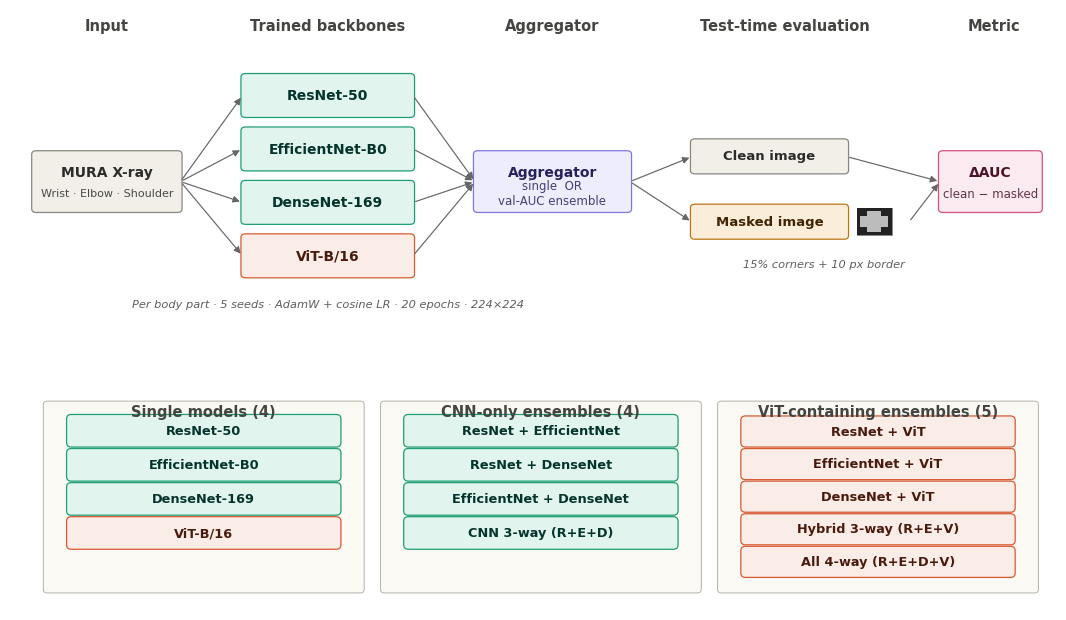

In [ ]:
"""
Methodology pipeline figure for the paper (Section 4).
Saves both PNG (for blog/preview) and PDF (for LaTeX).
"""
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

# ---------- color scheme (matches the data figures) ----------
COLORS = {
    'gray':   {'fill': '#F1EFE8', 'edge': '#888780', 'text': '#2C2C2A'},
    'teal':   {'fill': '#E1F5EE', 'edge': '#1D9E75', 'text': '#04342C'},
    'coral':  {'fill': '#FAECE7', 'edge': '#D85A30', 'text': '#4A1B0C'},
    'purple': {'fill': '#EEEDFE', 'edge': '#7F77DD', 'text': '#26215C'},
    'amber':  {'fill': '#FAEEDA', 'edge': '#BA7517', 'text': '#412402'},
    'pink':   {'fill': '#FBEAF0', 'edge': '#D4537E', 'text': '#4B1528'},
}

# ---------- helpers ----------
def box(ax, x, y, w, h, title, subtitle=None, color='gray', t_size=10, s_size=8.5):
    c = COLORS[color]
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.02,rounding_size=0.06",
                          facecolor=c['fill'], edgecolor=c['edge'], linewidth=0.9)
    ax.add_patch(rect)
    if subtitle:
        # support multi-line subtitle via "\n"
        ax.text(x + w/2, y + h*0.66, title, ha='center', va='center',
                fontsize=t_size, fontweight='bold', color=c['text'])
        ax.text(x + w/2, y + h*0.30, subtitle, ha='center', va='center',
                fontsize=s_size, color=c['text'], alpha=0.85)
    else:
        ax.text(x + w/2, y + h/2, title, ha='center', va='center',
                fontsize=t_size, fontweight='bold', color=c['text'])

def arr(ax, x1, y1, x2, y2, color='#666666', lw=0.85):
    a = FancyArrowPatch((x1, y1), (x2, y2),
                        arrowstyle='-|>', mutation_scale=10,
                        color=color, linewidth=lw, shrinkA=2, shrinkB=2)
    ax.add_patch(a)

def mask_icon(ax, cx, cy, size=0.4):
    """Tiny visual showing a masked X-ray: black border + 4 corner squares."""
    half = size / 2
    # Anatomy area (gray)
    ax.add_patch(Rectangle((cx-half, cy-half), size, size,
                           facecolor='#bcbcbc', edgecolor='#444', linewidth=0.4))
    # Border strip (black, ~10% on each side)
    bw = size * 0.10
    for r in [
        Rectangle((cx-half, cy-half), size, bw),       # bottom
        Rectangle((cx-half, cy+half-bw), size, bw),    # top
        Rectangle((cx-half, cy-half), bw, size),       # left
        Rectangle((cx+half-bw, cy-half), bw, size),    # right
    ]:
        r.set_facecolor('#222'); r.set_edgecolor('none')
        ax.add_patch(r)
    # 4 corner masks (~25% of side)
    cs = size * 0.30
    for cx_c, cy_c in [
        (cx-half, cy-half), (cx+half-cs, cy-half),
        (cx-half, cy+half-cs), (cx+half-cs, cy+half-cs),
    ]:
        ax.add_patch(Rectangle((cx_c, cy_c), cs, cs,
                               facecolor='#222', edgecolor='none'))

# ---------- figure ----------
fig = plt.figure(figsize=(13.5, 7.8))
gs = fig.add_gridspec(2, 1, height_ratios=[1.55, 1], hspace=0.12)
ax_p = fig.add_subplot(gs[0])
ax_c = fig.add_subplot(gs[1])
for a, ymax in [(ax_p, 5.8), (ax_c, 3.0)]:
    a.set_xlim(0, 13.5); a.set_ylim(0, ymax); a.axis('off')

# === TOP: pipeline ===
# Section headers
for x, lbl in [(1.25, 'Input'), (4.1, 'Trained backbones'),
               (7.0, 'Aggregator'), (10.0, 'Test-time evaluation'),
               (12.7, 'Metric')]:
    ax_p.text(x, 5.45, lbl, fontsize=10.5, fontweight='bold',
              ha='center', color='#444441')

# Input
box(ax_p, 0.3, 2.4, 1.9, 1.0, 'MURA X-ray', 'Wrist · Elbow · Shoulder', 'gray', s_size=8)

# Backbones (4 stacked)
box(ax_p, 3.0, 4.0, 2.2, 0.7, 'ResNet-50', None, 'teal')
box(ax_p, 3.0, 3.1, 2.2, 0.7, 'EfficientNet-B0', None, 'teal')
box(ax_p, 3.0, 2.2, 2.2, 0.7, 'DenseNet-169', None, 'teal')
box(ax_p, 3.0, 1.3, 2.2, 0.7, 'ViT-B/16', None, 'coral')

ax_p.text(4.1, 0.78,
          'Per body part · 5 seeds · AdamW + cosine LR · 20 epochs · 224×224',
          fontsize=8.2, ha='center', color='#5F5E5A', style='italic')

# Aggregator
box(ax_p, 6.0, 2.4, 2.0, 1.0,
    'Aggregator', 'single  OR\nval-AUC ensemble', 'purple')

# Test-time eval (clean & masked)
box(ax_p, 8.8, 3.05, 2.0, 0.55, 'Clean image', None, 'gray', t_size=9.5)
box(ax_p, 8.8, 1.95, 2.0, 0.55, 'Masked image', None, 'amber', t_size=9.5)
mask_icon(ax_p, 11.15, 2.225, size=0.45)
ax_p.text(10.5, 1.45, '15% corners + 10 px border',
          fontsize=8.2, ha='center', color='#5F5E5A', style='italic')

# Metric
box(ax_p, 12.0, 2.4, 1.3, 1.0, 'ΔAUC', 'clean − masked', 'pink')

# Arrows
# Input → 4 backbones
for y in [4.35, 3.45, 2.55, 1.65]:
    arr(ax_p, 2.2, 2.9, 3.0, y)
# 4 backbones → aggregator
for y in [4.35, 3.45, 2.55, 1.65]:
    arr(ax_p, 5.2, y, 6.0, 2.9)
# Aggregator → eval (split)
arr(ax_p, 8.0, 2.9, 8.8, 3.32)
arr(ax_p, 8.0, 2.9, 8.8, 2.22)
# Eval → ΔAUC (converge)
arr(ax_p, 10.8, 3.32, 12.0, 2.9)
arr(ax_p, 11.6, 2.22, 12.0, 2.9)

# === BOTTOM: configurations ===
group_w = 4.1
gap = 0.25
group_h = 2.55
y_base = 0.25
y_title = y_base + group_h - 0.18

groups = [
    ('Single models (4)',
     [('ResNet-50', 'teal'), ('EfficientNet-B0', 'teal'),
      ('DenseNet-169', 'teal'), ('ViT-B/16', 'coral')]),
    ('CNN-only ensembles (4)',
     [('ResNet + EfficientNet', 'teal'), ('ResNet + DenseNet', 'teal'),
      ('EfficientNet + DenseNet', 'teal'), ('CNN 3-way (R+E+D)', 'teal')]),
    ('ViT-containing ensembles (5)',
     [('ResNet + ViT', 'coral'), ('EfficientNet + ViT', 'coral'),
      ('DenseNet + ViT', 'coral'), ('Hybrid 3-way (R+E+V)', 'coral'),
      ('All 4-way (R+E+D+V)', 'coral')]),
]

x_cursor = 0.45
for title, items in groups:
    # group container
    ax_c.add_patch(FancyBboxPatch(
        (x_cursor, y_base), group_w, group_h,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        facecolor='#FAF9F4', edgecolor='#B4B2A9', linewidth=0.7))
    ax_c.text(x_cursor + group_w/2, y_title, title,
              fontsize=10.5, fontweight='bold', ha='center', color='#444441')
    # items
    n = len(items)
    avail_h = group_h - 0.55
    item_h = min(0.40, (avail_h - 0.1) / n)
    for i, (name, color) in enumerate(items):
        y_i = y_title - 0.40 - i * (item_h + 0.06)
        box(ax_c, x_cursor + 0.3, y_i, group_w - 0.6, item_h,
            name, None, color, t_size=9.3)
    x_cursor += group_w + gap
plt.savefig('methodology_pipeline.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('methodology_pipeline.pdf', bbox_inches='tight', facecolor='white')

from google.colab import files
files.download('methodology_pipeline.png')
files.download('methodology_pipeline.pdf')

=== Single model, single dataset (mean across 5 seeds, mask=15%) ===

-- Clean AUC --
body_part        XR_ELBOW  XR_SHOULDER  XR_WRIST
model                                           
densenet169        0.9209       0.8561    0.9126
efficientnet_b0    0.9157       0.8525    0.9083
resnet50           0.9209       0.8473    0.9006
vit                0.8899       0.7771    0.8738

-- Delta AUC (higher = more shortcut reliance) --
body_part        XR_ELBOW  XR_SHOULDER  XR_WRIST
model                                           
densenet169        0.0022      -0.0037    0.0018
efficientnet_b0   -0.0000       0.0004    0.0042
resnet50           0.0033       0.0006    0.0021
vit                0.0738       0.0388    0.0484

=== Checkpoint verification ===
All checkpoints present for 4 models x 3 BPs x 5 seeds.


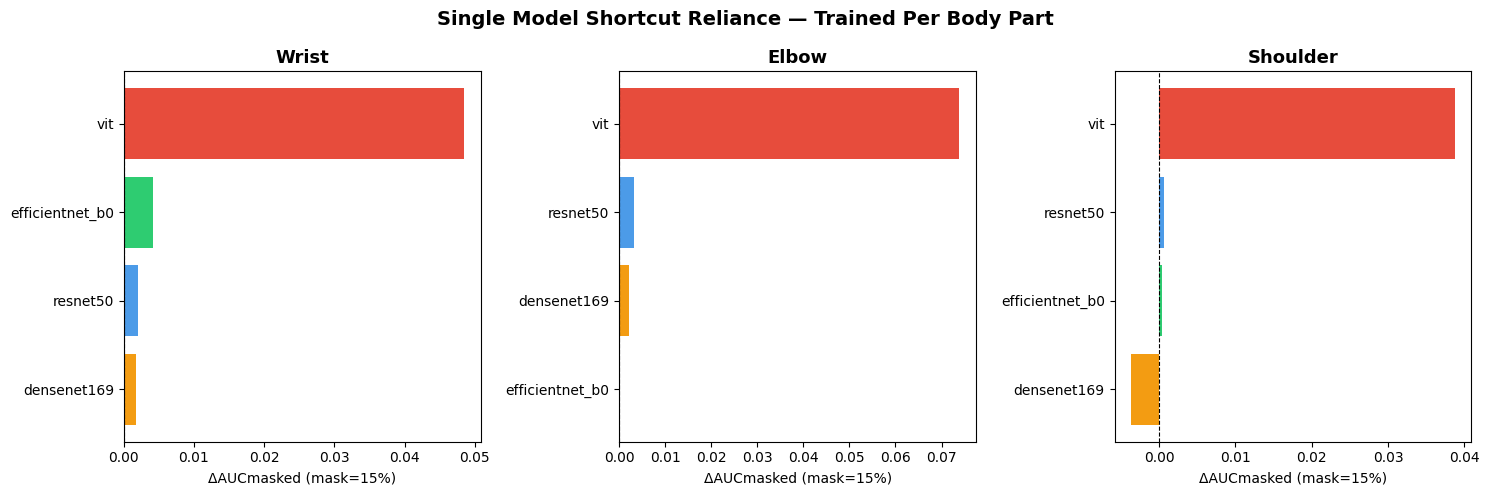


Saved: single_model_delta_auc.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# from google.colab import drive
# drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
delta_path = f'{BASE}/delta_auc_results.csv'

BPS  = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']
MASK = 0.15
SINGLE_MODELS = ['resnet50', 'efficientnet_b0', 'densenet169', 'vit']

# Load and filter: single models, 3 body parts, mask=0.15
df = pd.read_csv(delta_path)
df = df[
    df['model'].isin(SINGLE_MODELS) &
    df['body_part'].isin(BPS) &
    (df['mask_size'] == MASK)
]

# Average across 5 seeds
avg = df.groupby(['model', 'body_part'])[['clean_auc', 'delta_auc']].mean().round(4)

print('=== Single model, single dataset (mean across 5 seeds, mask=15%) ===')
print()
print('-- Clean AUC --')
print(avg['clean_auc'].unstack('body_part').to_string())
print()
print('-- Delta AUC (higher = more shortcut reliance) --')
print(avg['delta_auc'].unstack('body_part').to_string())

# Verify checkpoint files exist for each model/bp/seed combo
import os
print('\n=== Checkpoint verification ===')
checkpoint_dir = '/content/drive/MyDrive/Ml_Project class/mura_checkpoints'
seeds = [0, 1, 7, 21, 42]
missing = []
for model in SINGLE_MODELS:
    for bp in BPS:
        for seed in seeds:
            fname = f'{model}_{bp}_seed{seed}_best.pt'
            fpath = os.path.join(checkpoint_dir, fname)
            if not os.path.exists(fpath):
                missing.append(fname)
if missing:
    print(f'Missing {len(missing)} checkpoints:')
    for m in missing:
        print(' ', m)
else:
    print('All checkpoints present for 4 models x 3 BPs x 5 seeds.')

# Bar chart
bp_labels = {'XR_WRIST': 'Wrist', 'XR_ELBOW': 'Elbow', 'XR_SHOULDER': 'Shoulder'}
model_colors = {
    'resnet50': '#4c9be8',
    'efficientnet_b0': '#2ecc71',
    'densenet169': '#f39c12',
    'vit': '#e74c3c'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, bp in zip(axes, BPS):
    sub = avg['delta_auc'].unstack('body_part')[bp].reset_index()
    sub.columns = ['model', 'delta_auc']
    sub = sub.sort_values('delta_auc')
    colors = [model_colors[m] for m in sub['model']]
    ax.barh(sub['model'], sub['delta_auc'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(bp_labels[bp], fontsize=13, fontweight='bold')
    ax.set_xlabel('ΔAUCmasked (mask=15%)', fontsize=10)

fig.suptitle('Single Model Shortcut Reliance — Trained Per Body Part', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('single_model_delta_auc.png', bbox_inches='tight')
plt.show()
print('\nSaved: single_model_delta_auc.png')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Bootstrap loaded from: /content/drive/MyDrive/Ml_Project class/bootstrap_results.csv

TABLE 2a: Single Models — Clean AUC and ΔAUCmasked (mask=15%, mean 5 seeds)
Model                 Wrist AUC   Wrist ΔAUC  Elbow AUC   Elbow ΔAUC  Shoulder AUC  Shoulder ΔAUC
---------------------------------------------------------------------------
ResNet-50                0.9006      +0.0021     0.9209      +0.0033        0.8473        +0.0006
EffNet-B0                0.9083      +0.0042     0.9157      -0.0000        0.8525        +0.0004
DenseNet-169             0.9126      +0.0018     0.9209      +0.0022        0.8561        -0.0037
ViT-B/16                 0.8738      +0.0484     0.8899      +0.0738        0.7771        +0.0388

TABLE 2b: Key Ensembles — Clean AUC and ΔAUCmasked (mask=15%, mean 5 seeds)
Ensemble              Wrist AUC   Wrist ΔAUC  Elbow AUC   Elbow ΔA

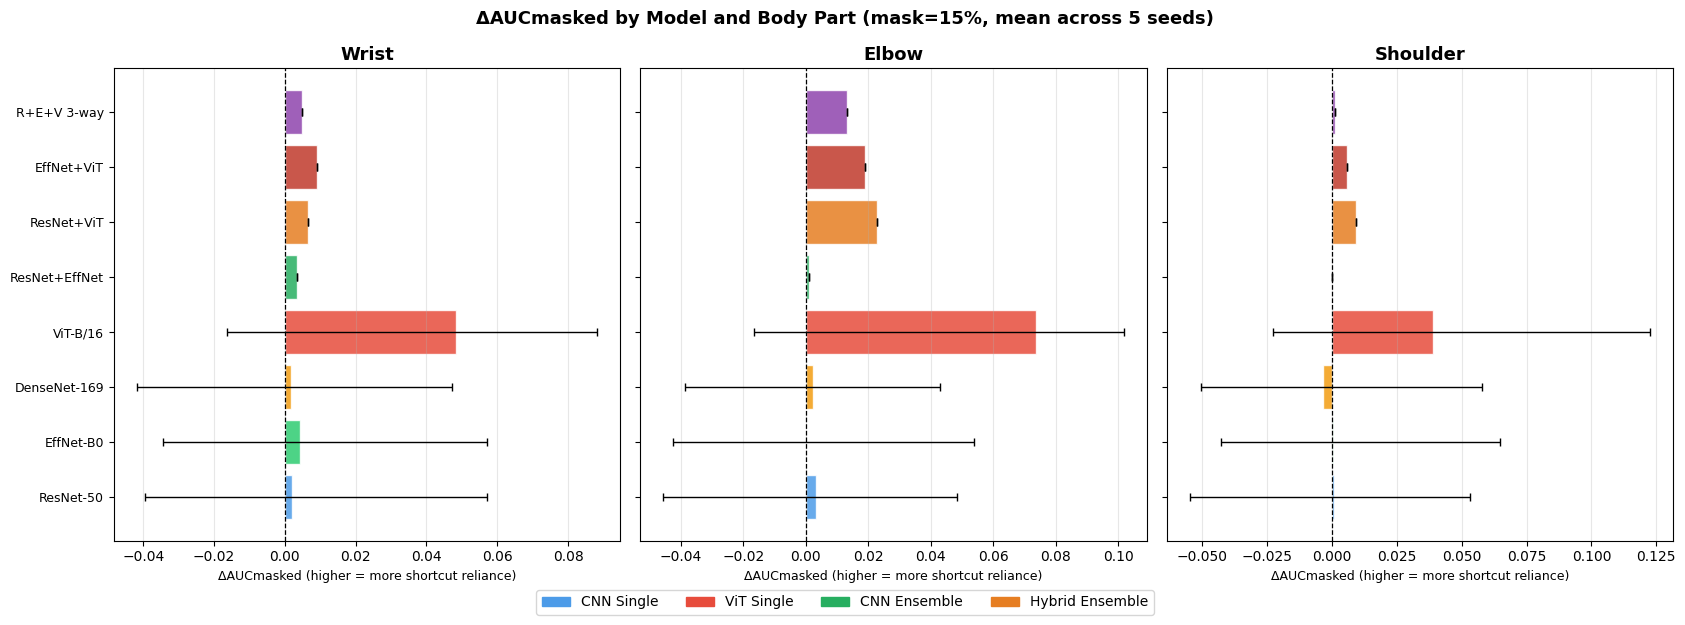


Saved to Drive: results_figure.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# ── paths ────────────────────────────────────────────────────────────────
BASE  = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
BOOT_PATH = '/content/drive/MyDrive/Ml_Project class/bootstrap_results.csv'

BPS      = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']
MASK     = 0.15
BP_LABELS = {'XR_WRIST': 'Wrist', 'XR_ELBOW': 'Elbow', 'XR_SHOULDER': 'Shoulder'}

single_models = ['resnet50', 'efficientnet_b0', 'densenet169', 'vit']
key_ensembles = ['resnet_effnet', 'resnet_vit', 'effnet_vit', 'hybrid_3way']

display_names = {
    'resnet50': 'ResNet-50', 'efficientnet_b0': 'EffNet-B0',
    'densenet169': 'DenseNet-169', 'vit': 'ViT-B/16',
    'resnet_effnet': 'ResNet+EffNet', 'resnet_vit': 'ResNet+ViT',
    'effnet_vit': 'EffNet+ViT', 'hybrid_3way': 'R+E+V 3-way'
}

# ── load ─────────────────────────────────────────────────────────────────
delta = pd.read_csv(f'{BASE}/delta_auc_results.csv')
edf   = pd.read_csv(f'{BASE}/ensemble_delta_auc_results.csv')

# try loading bootstrap from multiple possible locations
import os
for boot_path in [
    BOOT_PATH,
    f'{BASE}/bootstrap_results.csv',
    '/content/drive/MyDrive/Ml_Project class/eval_results_combined/bootstrap_results.csv',
    '/content/bootstrap_results.csv',
]:
    if os.path.exists(boot_path):
        boot = pd.read_csv(boot_path)
        print(f'Bootstrap loaded from: {boot_path}')
        break
else:
    print('WARNING: bootstrap_results.csv not found — CIs will be skipped')
    boot = None

# ── filter to 3 BPs ──────────────────────────────────────────────────────
d = delta[delta['body_part'].isin(BPS) & (delta['mask_size'] == MASK)]
e = edf[edf['body_part'].isin(BPS) & (edf['mask_size'] == MASK) &
        edf['ensemble'].isin(key_ensembles)]

single_avg = d.groupby(['model', 'body_part'])[['clean_auc', 'delta_auc']].mean().round(4)
ens_avg    = e.groupby(['ensemble', 'body_part'])[['clean_auc', 'delta_auc']].mean().round(4)

# ── TABLE: single models ─────────────────────────────────────────────────
print()
print('=' * 75)
print('TABLE 2a: Single Models — Clean AUC and ΔAUCmasked (mask=15%, mean 5 seeds)')
print('=' * 75)
print(f"{'Model':<20} {'Wrist AUC':>10} {'Wrist ΔAUC':>12} {'Elbow AUC':>10} {'Elbow ΔAUC':>12} {'Shoulder AUC':>13} {'Shoulder ΔAUC':>14}")
print('-' * 75)
for m in single_models:
    row = []
    for bp in BPS:
        auc  = single_avg.loc[(m, bp), 'clean_auc']
        dauc = single_avg.loc[(m, bp), 'delta_auc']
        row += [auc, dauc]
    print(f"{display_names[m]:<20} {row[0]:>10.4f} {row[1]:>+12.4f} {row[2]:>10.4f} {row[3]:>+12.4f} {row[4]:>13.4f} {row[5]:>+14.4f}")

# ── TABLE: ensembles ─────────────────────────────────────────────────────
print()
print('=' * 75)
print('TABLE 2b: Key Ensembles — Clean AUC and ΔAUCmasked (mask=15%, mean 5 seeds)')
print('=' * 75)
print(f"{'Ensemble':<20} {'Wrist AUC':>10} {'Wrist ΔAUC':>12} {'Elbow AUC':>10} {'Elbow ΔAUC':>12} {'Shoulder AUC':>13} {'Shoulder ΔAUC':>14}")
print('-' * 75)
for ens in key_ensembles:
    row = []
    for bp in BPS:
        auc  = ens_avg.loc[(ens, bp), 'clean_auc']
        dauc = ens_avg.loc[(ens, bp), 'delta_auc']
        row += [auc, dauc]
    print(f"{display_names[ens]:<20} {row[0]:>10.4f} {row[1]:>+12.4f} {row[2]:>10.4f} {row[3]:>+12.4f} {row[4]:>13.4f} {row[5]:>+14.4f}")

# ── TABLE: bootstrap CIs ─────────────────────────────────────────────────
if boot is not None:
    b = boot[boot['body_part'].isin(BPS) & boot['model'].isin(single_models)]
    print()
    print('=' * 75)
    print('TABLE 2c: Bootstrap 95% CIs on ΔAUCmasked (single models)')
    print('=' * 75)
    print(f"{'Model':<20} {'Body Part':<12} {'ΔAUC':>8} {'95% CI Lo':>12} {'95% CI Hi':>12}")
    print('-' * 75)
    for _, row in b.iterrows():
        print(f"{row['model']:<20} {BP_LABELS[row['body_part']]:<12} "
              f"{row['delta_auc']:>+8.4f} {row['delta_lo']:>+12.4f} {row['delta_hi']:>+12.4f}")

# ── FIGURE ───────────────────────────────────────────────────────────────
colors = {
    'resnet50': '#4c9be8', 'efficientnet_b0': '#2ecc71',
    'densenet169': '#f39c12', 'vit': '#e74c3c',
    'resnet_effnet': '#27ae60', 'resnet_vit': '#e67e22',
    'effnet_vit': '#c0392b', 'hybrid_3way': '#8e44ad'
}

all_configs = single_models + key_ensembles
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, bp in zip(axes, BPS):
    vals, labels, bar_colors, errs = [], [], [], []
    for cfg in all_configs:
        if cfg in single_models:
            v = single_avg.loc[(cfg, bp), 'delta_auc']
            if boot is not None:
                row = b[(b['model'] == cfg) & (b['body_part'] == bp)]
                if len(row):
                    lo = row['delta_lo'].values[0]
                    hi = row['delta_hi'].values[0]
                    errs.append([v - lo, hi - v])
                else:
                    errs.append([0, 0])
            else:
                errs.append([0, 0])
        else:
            v = ens_avg.loc[(cfg, bp), 'delta_auc']
            errs.append([0, 0])
        vals.append(v)
        labels.append(display_names[cfg])
        bar_colors.append(colors[cfg])

    errs = np.array(errs).T
    y_pos = np.arange(len(vals))
    ax.barh(y_pos, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.errorbar(vals, y_pos, xerr=errs, fmt='none', color='black',
                capsize=3, linewidth=1)
    ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(BP_LABELS[bp], fontsize=13, fontweight='bold')
    ax.set_xlabel('ΔAUCmasked (higher = more shortcut reliance)', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

patches = [
    mpatches.Patch(color='#4c9be8', label='CNN Single'),
    mpatches.Patch(color='#e74c3c', label='ViT Single'),
    mpatches.Patch(color='#27ae60', label='CNN Ensemble'),
    mpatches.Patch(color='#e67e22', label='Hybrid Ensemble'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('ΔAUCmasked by Model and Body Part (mask=15%, mean across 5 seeds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ml_Project class/results_figure.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('\nSaved to Drive: results_figure.png')

In [ ]:
import pandas as pd
from IPython.display import display, HTML
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
BPS  = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']
MASK = 0.15

single_models = ['resnet50', 'efficientnet_b0', 'densenet169', 'vit']
key_ensembles = ['resnet_effnet', 'resnet_dense', 'effnet_dense', 'cnn_3way', 'resnet_vit', 'effnet_vit', 'dense_vit', 'hybrid_3way', 'all_4way']

display_names = {
    'resnet50': 'ResNet-50', 'efficientnet_b0': 'EfficientNet-B0',
    'densenet169': 'DenseNet-169', 'vit': 'ViT-B/16',
    'resnet_effnet': 'ResNet+EffNet', 'resnet_dense': 'ResNet+DenseNet',
    'effnet_dense': 'EffNet+DenseNet', 'cnn_3way': 'CNN 3-way (R+E+D)',
    'resnet_vit': 'ResNet+ViT', 'effnet_vit': 'EffNet+ViT',
    'dense_vit': 'DenseNet+ViT', 'hybrid_3way': 'R+E+V 3-way',
    'all_4way': 'All 4-way (R+E+D+V)',
}
type_labels = {
    'resnet50': 'Single (CNN)', 'efficientnet_b0': 'Single (CNN)',
    'densenet169': 'Single (CNN)', 'vit': 'Single (ViT)',
    'resnet_effnet': 'CNN Ensemble', 'resnet_dense': 'CNN Ensemble',
    'effnet_dense': 'CNN Ensemble', 'cnn_3way': 'CNN Ensemble',
    'resnet_vit': 'Hybrid', 'effnet_vit': 'Hybrid',
    'dense_vit': 'Hybrid', 'hybrid_3way': 'Hybrid', 'all_4way': 'Hybrid',
}

delta = pd.read_csv(f'{BASE}/delta_auc_results.csv')
edf   = pd.read_csv(f'{BASE}/ensemble_delta_auc_results.csv')

d = delta[delta['body_part'].isin(BPS) & (delta['mask_size'] == MASK)]
e = edf[edf['body_part'].isin(BPS) & (edf['mask_size'] == MASK) & edf['ensemble'].isin(key_ensembles)]

single_avg = d.groupby(['model','body_part'])[['clean_auc','delta_auc']].mean().round(4)
ens_avg    = e.groupby(['ensemble','body_part'])[['clean_auc','delta_auc']].mean().round(4)

rows = []
for cfg in single_models + key_ensembles:
    avg = single_avg if cfg in single_models else ens_avg
    row = {'Model': display_names[cfg], 'Type': type_labels[cfg]}
    for bp, label in [('XR_WRIST','Wrist'),('XR_ELBOW','Elbow'),('XR_SHOULDER','Shoulder')]:
        row[f'{label} AUC']  = avg.loc[(cfg, bp), 'clean_auc']
        row[f'{label} ΔAUC'] = avg.loc[(cfg, bp), 'delta_auc']
    rows.append(row)

df = pd.DataFrame(rows)

def highlight(row):
    styles = [''] * len(row)
    idx = list(row.index)
    if row['Type'] == 'Single (ViT)':
        for col in ['Wrist ΔAUC','Elbow ΔAUC','Shoulder ΔAUC']:
            styles[idx.index(col)] = 'background-color: #c0392b; color: white; font-weight: bold; font-size: 16px'
    if row['Type'] == 'CNN Ensemble':
        for col in ['Wrist ΔAUC','Elbow ΔAUC','Shoulder ΔAUC']:
            styles[idx.index(col)] = 'background-color: #1e8449; color: white; font-weight: bold; font-size: 16px'
    return styles

def row_bg(row):
    colors = {
        'Single (CNN)': 'background-color: #d6eaf8; color: #1a252f',
        'Single (ViT)': 'background-color: #fadbd8; color: #1a252f',
        'CNN Ensemble': 'background-color: #d5f5e3; color: #1a252f',
        'Hybrid':       'background-color: #fef9e7; color: #1a252f',
    }
    return [colors.get(row['Type'], '')] * len(row)

styled = (df.style
    .apply(row_bg, axis=1)
    .apply(highlight, axis=1)
    .format({
        'Wrist AUC': '{:.4f}', 'Elbow AUC': '{:.4f}', 'Shoulder AUC': '{:.4f}',
        'Wrist ΔAUC': '{:+.4f}', 'Elbow ΔAUC': '{:+.4f}', 'Shoulder ΔAUC': '{:+.4f}',
    })
    .hide(axis='index')
    .set_caption('Table 2: ΔAUCmasked — mask=15%, mean across 5 seeds')
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background','#1a252f'), ('color','white'),
            ('padding','14px 18px'), ('text-align','center'),
            ('font-size','15px')]},
        {'selector': 'td', 'props': [
            ('padding','13px 18px'), ('text-align','center'),
            ('font-size','15px')]},
        {'selector': 'caption', 'props': [
            ('font-size','15px'), ('font-weight','bold'), ('padding','10px'),
            ('color','black')]},
    ])
)

display(styled)

display(HTML("""
<div style="margin-top: 8px; font-size: 13px; font-family: Arial;">
  <span style="background:#d6eaf8; padding: 4px 10px; margin-right: 8px; border-radius: 4px; color:#1a252f">■ Single CNN</span>
  <span style="background:#fadbd8; padding: 4px 10px; margin-right: 8px; border-radius: 4px; color:#1a252f">■ Single ViT</span>
  <span style="background:#d5f5e3; padding: 4px 10px; margin-right: 8px; border-radius: 4px; color:#1a252f">■ CNN Ensemble</span>
  <span style="background:#fef9e7; padding: 4px 10px; margin-right: 8px; border-radius: 4px; color:#1a252f">■ Hybrid Ensemble</span>
  <span style="background:#c0392b; padding: 4px 10px; margin-right: 8px; border-radius: 4px; color:white">■ High shortcut reliance</span>
  <span style="background:#1e8449; padding: 4px 10px; border-radius: 4px; color:white">■ Most robust</span>
  <p style="margin-top: 8px; color: #555;">ΔAUCmasked = AUC(clean) − AUC(masked). Higher = more shortcut reliance. Mask covers 15% corners + 10px border. Results averaged across 5 random seeds.</p>
</div>
"""))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model,Type,Wrist AUC,Wrist ΔAUC,Elbow AUC,Elbow ΔAUC,Shoulder AUC,Shoulder ΔAUC
ResNet-50,Single (CNN),0.9006,+0.0021,0.9209,+0.0033,0.8473,+0.0006
EfficientNet-B0,Single (CNN),0.9083,+0.0042,0.9157,-0.0000,0.8525,+0.0004
DenseNet-169,Single (CNN),0.9126,+0.0018,0.9209,+0.0022,0.8561,-0.0037
ViT-B/16,Single (ViT),0.8738,+0.0484,0.8899,+0.0738,0.7771,+0.0388
ResNet+EffNet,CNN Ensemble,0.9117,+0.0035,0.9264,+0.0011,0.8651,-0.0002
ResNet+DenseNet,CNN Ensemble,0.9142,+0.0018,0.9273,+0.0030,0.8640,-0.0013
EffNet+DenseNet,CNN Ensemble,0.9173,+0.0026,0.9265,+0.0004,0.8677,-0.0026
CNN 3-way (R+E+D),CNN Ensemble,0.9168,+0.0024,0.9298,+0.0015,0.8706,-0.0017
ResNet+ViT,Hybrid,0.8985,+0.0065,0.9209,+0.0227,0.8405,+0.0094
EffNet+ViT,Hybrid,0.9023,+0.0090,0.9201,+0.0189,0.8405,+0.0056


In [ ]:
import pandas as pd
from IPython.display import display, HTML

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
BPS  = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']

delta = pd.read_csv(f'{BASE}/delta_auc_results.csv')
d = delta[delta['body_part'].isin(BPS)]

single_models = ['resnet50', 'efficientnet_b0', 'densenet169', 'vit']
display_names = {
    'resnet50': 'ResNet-50', 'efficientnet_b0': 'EfficientNet-B0',
    'densenet169': 'DenseNet-169', 'vit': 'ViT-B/16',
}

sweep = (d[d['model'].isin(single_models)]
         .groupby(['model', 'mask_size'])['delta_auc']
         .mean().round(4)
         .unstack('mask_size'))
sweep.index = [display_names[m] for m in sweep.index]
sweep.columns = [f'{int(c*100)}%' for c in sweep.columns]
sweep.index.name = 'Model'


def row_style(row):
    if row.name == 'ViT-B/16':
        return ['background-color: #e74c3c; color: white; font-weight: bold; font-size: 15px'] * len(row)
    return ['background-color: white; color: #1a252f; font-size: 15px'] * len(row)

styled = (sweep.style
    .apply(row_style, axis=1)
    .format(lambda v: f'{v:+.3f}')
    .set_caption('Table 3: Mean ΔAUCmasked across mask sizes (averaged across 3 body parts and 5 seeds)')
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [
            ('background-color', '#f8f9fa'),
            ('color', '#1a252f'),
            ('padding', '12px 18px'),
            ('text-align', 'center'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('border-bottom', '2px solid #dee2e6')]},
        {'selector': 'th.col_heading', 'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('padding', '12px 18px'),
            ('text-align', 'center'),
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('border-bottom', '2px solid #dee2e6')]},
        {'selector': 'td', 'props': [
            ('padding', '12px 18px'),
            ('text-align', 'center'),
            ('border-bottom', '1px solid #dee2e6')]},
        {'selector': 'caption', 'props': [
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('padding', '10px 0'),
            ('color', '#1a252f'),
            ('text-align', 'left')]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('box-shadow', '0 1px 3px rgba(0,0,0,0.1)')]},
    ])
)

display(styled)

display(HTML("""
<div style="margin-top:10px; font-size:13px; font-family:Arial; color:#555;">
  <span style="background:#e74c3c; padding:4px 12px; border-radius:4px; color:white; margin-right:8px">■ ViT-B/16</span>
  <span style="background:#f8f9fa; padding:4px 12px; border-radius:4px; color:#1a252f; border:1px solid #dee2e6">■ CNN models</span>
  <p style="margin-top:8px;">ViT separation is present at every threshold including 10%. CNN models only rise above baseline at 35–40% when the mask encroaches on anatomy.</p>
</div>
"""))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,10%,15%,20%,25%,30%,35%,40%
Model,,,,,,,
DenseNet-169,-0.001,+0.000,+0.001,+0.008,+0.022,+0.049,+0.118
EfficientNet-B0,-0.001,+0.002,+0.003,+0.009,+0.022,+0.038,+0.093
ResNet-50,+0.001,+0.002,+0.003,+0.009,+0.023,+0.046,+0.125
ViT-B/16,+0.037,+0.054,+0.066,+0.096,+0.123,+0.133,+0.211


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


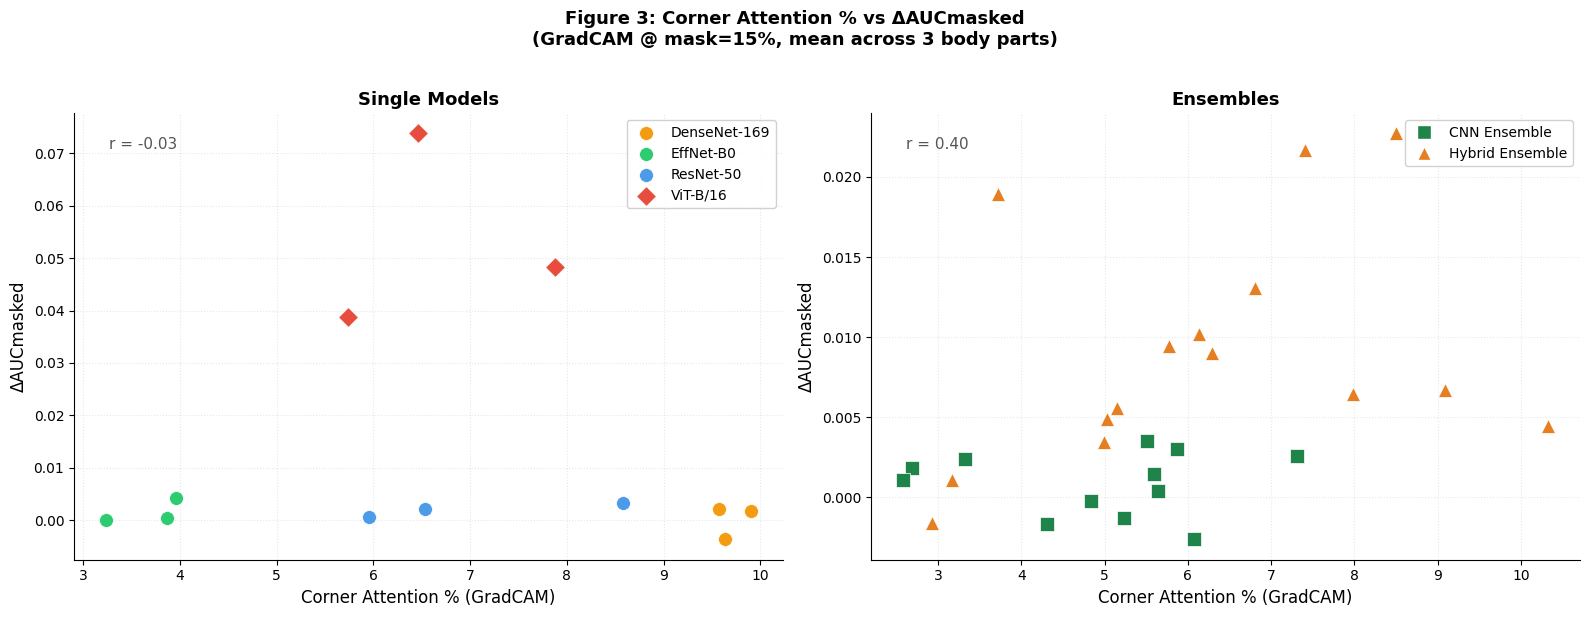

Saved: gradcam_scatter.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
BPS  = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']
BP_LABELS = {'XR_WRIST': 'Wrist', 'XR_ELBOW': 'Elbow', 'XR_SHOULDER': 'Shoulder'}

gc    = pd.read_csv(f'{BASE}/gradcam_overlap_results.csv')
delta = pd.read_csv(f'{BASE}/delta_auc_results.csv')
egc   = pd.read_csv(f'{BASE}/ensemble_gradcam_overlap.csv')
edf   = pd.read_csv(f'{BASE}/ensemble_delta_auc_results.csv')

gc3  = gc[gc['body_part'].isin(BPS) & (gc['mask_size']==0.15)]
d3   = delta[delta['body_part'].isin(BPS) & (delta['mask_size']==0.15)]
egc3 = egc[egc['body_part'].isin(BPS) & (egc['mask_size']==0.15)]
edf3 = edf[edf['body_part'].isin(BPS) & (edf['mask_size']==0.15)]

single = gc3.groupby(['model','body_part'])['attention_in_corner_pct'].mean().reset_index()
single = single.merge(d3.groupby(['model','body_part'])['delta_auc'].mean().reset_index(), on=['model','body_part'])

ens = egc3.groupby(['ensemble','body_part'])['attention_in_corner_pct'].mean().reset_index()
ens = ens.merge(edf3.groupby(['ensemble','body_part'])['delta_auc'].mean().reset_index(), on=['ensemble','body_part'])

cnn_ens = ['resnet_effnet','resnet_dense','effnet_dense','cnn_3way']
hybrids = ['resnet_vit','effnet_vit','dense_vit','hybrid_3way','all_4way']

display_names = {
    'resnet50': 'ResNet-50', 'efficientnet_b0': 'EffNet-B0',
    'densenet169': 'DenseNet-169', 'vit': 'ViT-B/16',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# ── left: single models ───────────────────────────────────────────────
ax = axes[0]
colors = {'resnet50':'#4c9be8','efficientnet_b0':'#2ecc71','densenet169':'#f39c12','vit':'#e74c3c'}
markers = {'resnet50':'o','efficientnet_b0':'o','densenet169':'o','vit':'D'}

for model in single['model'].unique():
    sub = single[single['model']==model]
    ax.scatter(sub['attention_in_corner_pct']*100, sub['delta_auc'],
               color=colors[model], marker=markers[model], s=100,
               label=display_names[model], zorder=3, edgecolors='white', linewidths=0.5)

ax.set_xlabel('Corner Attention % (GradCAM)', fontsize=12)
ax.set_ylabel('ΔAUCmasked', fontsize=12)
ax.set_title('Single Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

r = single['attention_in_corner_pct'].corr(single['delta_auc'])
ax.text(0.05, 0.92, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=11, color='#555')

# ── right: ensembles ──────────────────────────────────────────────────
ax = axes[1]
for _, row in ens.iterrows():
    if row['ensemble'] in cnn_ens:
        c, m, lbl = '#1e8449', 's', 'CNN Ensemble'
    else:
        c, m, lbl = '#e67e22', '^', 'Hybrid Ensemble'
    ax.scatter(row['attention_in_corner_pct']*100, row['delta_auc'],
               color=c, marker=m, s=100, zorder=3,
               edgecolors='white', linewidths=0.5)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#1e8449', markersize=10, label='CNN Ensemble'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#e67e22', markersize=10, label='Hybrid Ensemble'),
]
ax.legend(handles=legend_els, fontsize=10, framealpha=0.9)
ax.set_xlabel('Corner Attention % (GradCAM)', fontsize=12)
ax.set_ylabel('ΔAUCmasked', fontsize=12)
ax.set_title('Ensembles', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

r2 = ens['attention_in_corner_pct'].corr(ens['delta_auc'])
ax.text(0.05, 0.92, f'r = {r2:.2f}', transform=ax.transAxes,
        fontsize=11, color='#555')

fig.suptitle('Figure 3: Corner Attention % vs ΔAUCmasked\n(GradCAM @ mask=15%, mean across 3 body parts)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ml_Project class/gradcam_scatter.png',
            bbox_inches='tight', dpi=200, facecolor='white')
plt.show()
print('Saved: gradcam_scatter.png')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


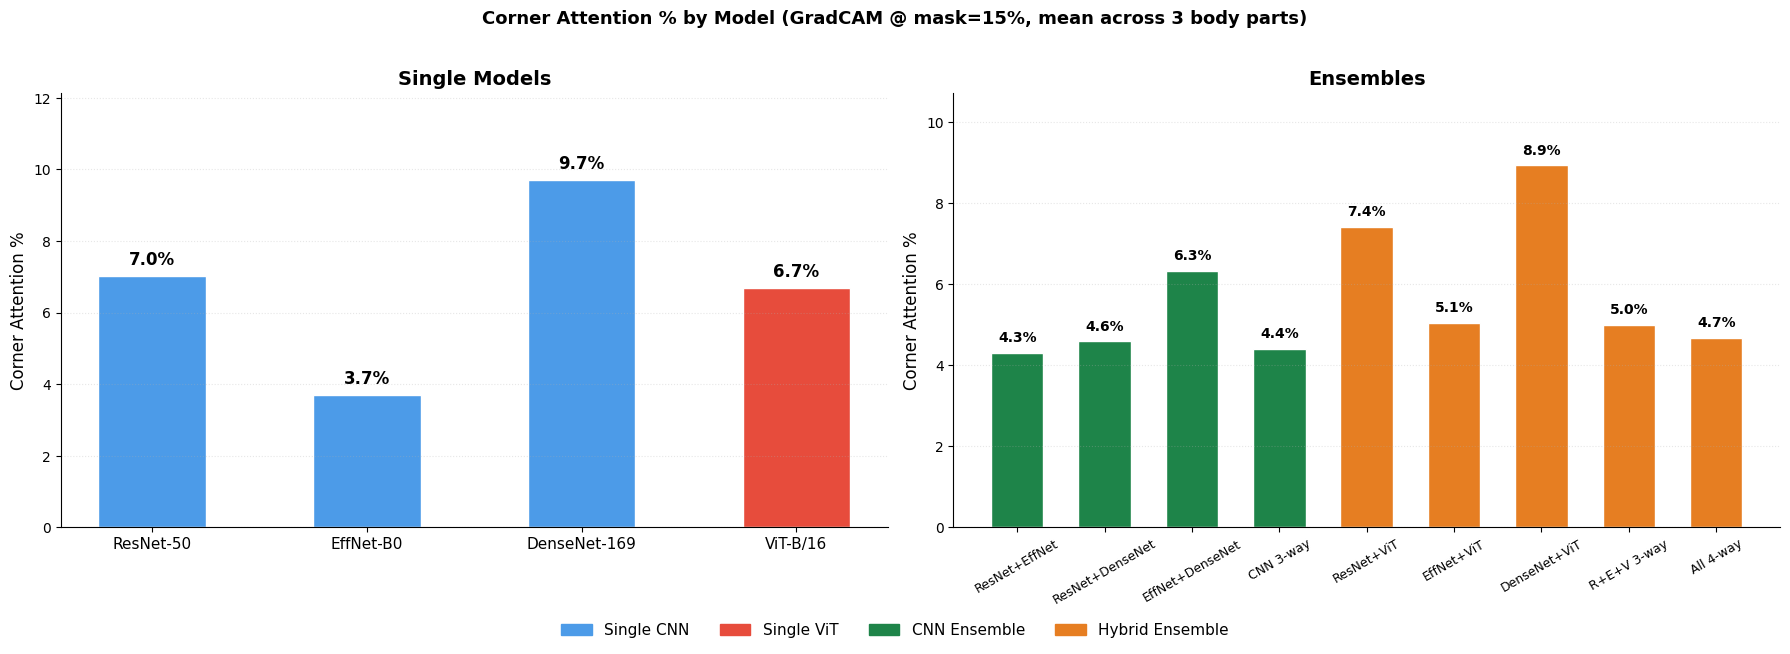

Saved: corner_attention_bar.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
BPS  = ['XR_WRIST', 'XR_ELBOW', 'XR_SHOULDER']

gc  = pd.read_csv(f'{BASE}/gradcam_overlap_results.csv')
egc = pd.read_csv(f'{BASE}/ensemble_gradcam_overlap.csv')

gc3  = gc[gc['body_part'].isin(BPS) & (gc['mask_size']==0.15)]
egc3 = egc[egc['body_part'].isin(BPS) & (egc['mask_size']==0.15)]

single_avg = gc3.groupby('model')['attention_in_corner_pct'].mean() * 100
ens_avg    = egc3.groupby('ensemble')['attention_in_corner_pct'].mean() * 100

display_names = {
    'resnet50': 'ResNet-50', 'efficientnet_b0': 'EffNet-B0',
    'densenet169': 'DenseNet-169', 'vit': 'ViT-B/16',
    'resnet_effnet': 'ResNet+EffNet', 'resnet_dense': 'ResNet+DenseNet',
    'effnet_dense': 'EffNet+DenseNet', 'cnn_3way': 'CNN 3-way',
    'resnet_vit': 'ResNet+ViT', 'effnet_vit': 'EffNet+ViT',
    'dense_vit': 'DenseNet+ViT', 'hybrid_3way': 'R+E+V 3-way',
    'all_4way': 'All 4-way',
}
colors_single = {
    'resnet50': '#4c9be8', 'efficientnet_b0': '#4c9be8',
    'densenet169': '#4c9be8', 'vit': '#e74c3c',
}
cnn_ens  = ['resnet_effnet','resnet_dense','effnet_dense','cnn_3way']
hybrids  = ['resnet_vit','effnet_vit','dense_vit','hybrid_3way','all_4way']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

# ── left: single models ───────────────────────────────────────────────
ax = axes[0]
order = ['resnet50','efficientnet_b0','densenet169','vit']
vals  = [single_avg[m] for m in order]
names = [display_names[m] for m in order]
clrs  = [colors_single[m] for m in order]

bars = ax.bar(names, vals, color=clrs, edgecolor='white', width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Corner Attention %', fontsize=12)
ax.set_title('Single Models', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(vals)*1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.tick_params(axis='x', labelsize=11)

# ── right: ensembles ──────────────────────────────────────────────────
ax = axes[1]
ens_order = cnn_ens + hybrids
ens_vals  = [ens_avg[e] for e in ens_order]
ens_names = [display_names[e] for e in ens_order]
ens_clrs  = ['#1e8449']*4 + ['#e67e22']*5

bars = ax.bar(ens_names, ens_vals, color=ens_clrs, edgecolor='white', width=0.6)
for bar, val in zip(bars, ens_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Corner Attention %', fontsize=12)
ax.set_title('Ensembles', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(ens_vals)*1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.tick_params(axis='x', labelsize=9, rotation=30)

import matplotlib.patches as mpatches
legend_els = [
    mpatches.Patch(color='#4c9be8', label='Single CNN'),
    mpatches.Patch(color='#e74c3c', label='Single ViT'),
    mpatches.Patch(color='#1e8449', label='CNN Ensemble'),
    mpatches.Patch(color='#e67e22', label='Hybrid Ensemble'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.05), frameon=False)

fig.suptitle('Corner Attention % by Model (GradCAM @ mask=15%, mean across 3 body parts)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ml_Project class/corner_attention_bar.png',
            bbox_inches='tight', dpi=200, facecolor='white')
plt.show()
print('Saved: corner_attention_bar.png')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


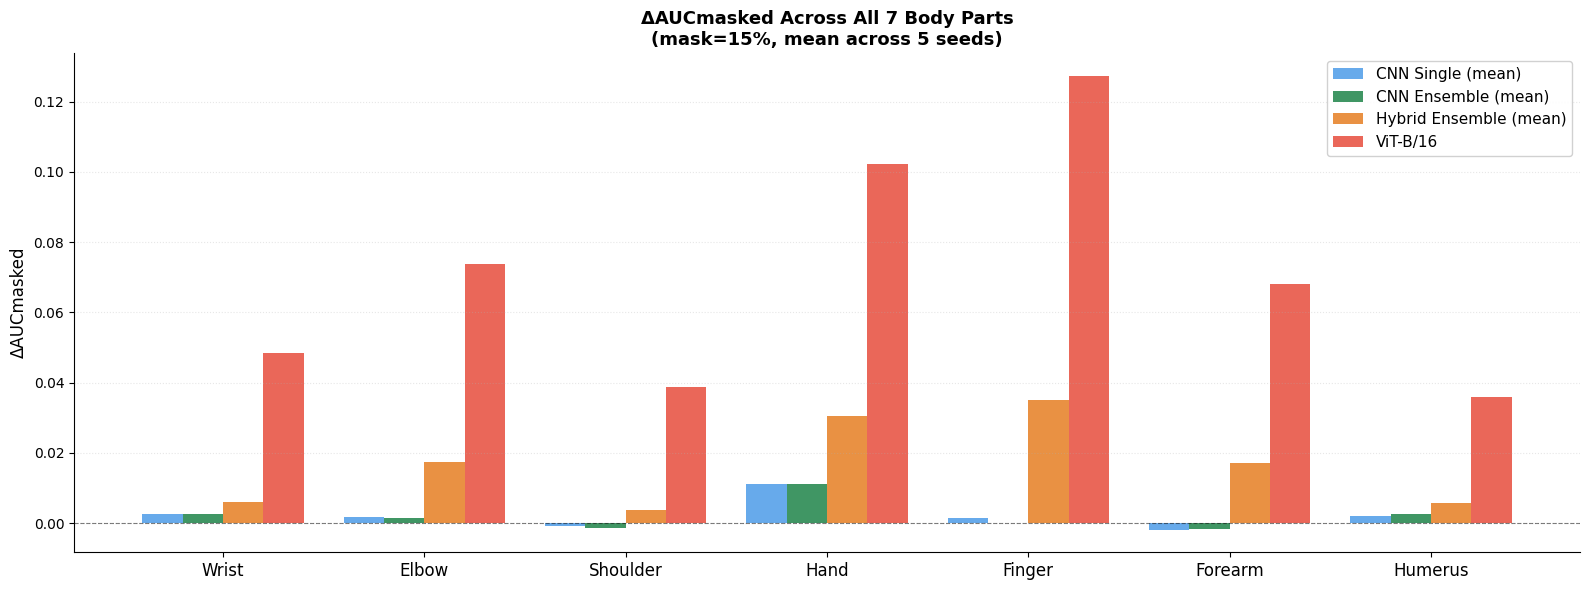

Saved: all7bp_figure.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Ml_Project class/eval_results_combined'
ALL_BPS = ['XR_WRIST','XR_ELBOW','XR_SHOULDER','XR_HAND','XR_FINGER','XR_FOREARM','XR_HUMERUS']
BP_LABELS = {
    'XR_WRIST':'Wrist','XR_ELBOW':'Elbow','XR_SHOULDER':'Shoulder',
    'XR_HAND':'Hand','XR_FINGER':'Finger','XR_FOREARM':'Forearm','XR_HUMERUS':'Humerus'
}
MASK = 0.15

delta = pd.read_csv(f'{BASE}/delta_auc_results.csv')
edf   = pd.read_csv(f'{BASE}/ensemble_delta_auc_results.csv')

d = delta[delta['body_part'].isin(ALL_BPS) & (delta['mask_size']==MASK)]
e = edf[edf['body_part'].isin(ALL_BPS) & (edf['mask_size']==MASK)]

cnn_only = ['resnet_effnet','resnet_dense','effnet_dense','cnn_3way']
hybrids  = ['resnet_vit','effnet_vit','dense_vit','hybrid_3way','all_4way']
cnns     = ['resnet50','efficientnet_b0','densenet169']

vit_bp    = d[d['model']=='vit'].groupby('body_part')['delta_auc'].mean()
cnn_bp    = d[d['model'].isin(cnns)].groupby('body_part')['delta_auc'].mean()
cnn_ens_bp = e[e['ensemble'].isin(cnn_only)].groupby('body_part')['delta_auc'].mean()
hyb_bp    = e[e['ensemble'].isin(hybrids)].groupby('body_part')['delta_auc'].mean()

bp_order = ['XR_WRIST','XR_ELBOW','XR_SHOULDER','XR_HAND','XR_FINGER','XR_FOREARM','XR_HUMERUS']
labels = [BP_LABELS[bp] for bp in bp_order]
x = np.arange(len(bp_order))
w = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(x - 1.5*w, [cnn_bp[bp] for bp in bp_order],    w, label='CNN Single (mean)', color='#4c9be8', alpha=0.85)
ax.bar(x - 0.5*w, [cnn_ens_bp[bp] for bp in bp_order], w, label='CNN Ensemble (mean)', color='#1e8449', alpha=0.85)
ax.bar(x + 0.5*w, [hyb_bp[bp] for bp in bp_order],    w, label='Hybrid Ensemble (mean)', color='#e67e22', alpha=0.85)
ax.bar(x + 1.5*w, [vit_bp[bp] for bp in bp_order],    w, label='ViT-B/16', color='#e74c3c', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('ΔAUCmasked', fontsize=12)
ax.set_title('ΔAUCmasked Across All 7 Body Parts\n(mask=15%, mean across 5 seeds)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ml_Project class/all7bp_figure.png',
            bbox_inches='tight', dpi=200, facecolor='white')
plt.show()
print('Saved: all7bp_figure.png')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

input_file = "/content/drive/MyDrive/Ml_Project class/mura_shortcut_learningFINAL.ipynb"
output_file = "/content/drive/MyDrive/Ml_Project class/fixed_mura_shortcut_learning_VIT3nontrainedFINAL.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Fixed notebook saved as:", output_file)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Ml_Project class/mura_shortcut_learningFINAL.ipynb'